# **Bike Sharing**

[Bike Sharing Dataset](https://drive.google.com/drive/folders/17Mw_4wSRiBB5vLLQJN137AlAbyB3CLFx)

# **Contents**

1. Business Problem Understanding
2. Data Understanding
3. Data Preprocessing
4. Modeling
5. Conclusion
6. Recommendation
---

# **Business Problem Understanding**

## **Context**
Sistem berbagi sepeda (*Bike Sharing*) adalah inovasi modern dalam penyewaan sepeda, di mana seluruh proses, mulai dari keanggotaan, penyewaan, hingga pengembalian, telah sepenuhnya otomatis. Melalui sistem ini, pengguna dapat dengan mudah menyewa sepeda dari satu lokasi dan mengembalikannya di lokasi lain. Saat ini, terdapat lebih dari 500 program berbagi sepeda di seluruh dunia dengan lebih dari 500 ribu sepeda yang beroperasi. Sistem ini semakin diminati karena perannya yang signifikan dalam mengatasi masalah lalu lintas, mendukung pelestarian lingkungan, dan meningkatkan kesehatan masyarakat.

Selain manfaat praktisnya dalam kehidupan sehari-hari, data yang dihasilkan oleh sistem berbagi sepeda memiliki karakteristik unik yang menjadikannya menarik untuk penelitian. Tidak seperti moda transportasi lainnya, seperti bus atau kereta bawah tanah, sistem ini secara eksplisit mencatat durasi perjalanan, lokasi keberangkatan, dan lokasi pengembalian. Hal ini menjadikan sistem berbagi sepeda sebagai jaringan sensor virtual yang dapat digunakan untuk memahami pola mobilitas di dalam kota. Sehingga, pihak yang memiliki urgensi tinggi dalam memahami data ini adalah **divisi logistik (pengadaan)**. Dengan memanfaatkan data ini, berbagai peristiwa penting di kota dapat dideteksi dan dianalisis, memberikan wawasan berharga untuk perencanaan dan pengambilan keputusan yang lebih baik. 

## **Problem Statement**
Tantangan utama dalam sistem berbagi sepeda adalah memastikan ketersediaan sepeda yang cukup untuk memenuhi permintaan pengguna dalam berbagai kondisi dan situasi. Ketidakseimbangan pasokan dapat menyebabkan kegagalan memenuhi kebutuhan pengguna, yang berpotensi menurunkan kepuasan dan kepercayaan pelanggan. Sebaliknya, jika jumlah sepeda yang tersedia terlalu banyak, hal ini dapat mengakibatkan inefisiensi operasional, dengan banyaknya unit sepeda yang tidak terpakai. Kondisi tersebut dapat meningkatkan biaya logistik, perawatan, dan manajemen sepeda secara keseluruhan. Melansir dari [Fasterwheel.com](https://fasterwheeler.com/id/electric-bike/lyft-electric-bike-2024-699), harga satu unit E-Bike yang digunakan oleh perusahaan Capital Bikeshare adalah Rp 10.575.000. Dengan demikian, jika terjadi inefisiensi operasional, maka biaya yang dikeluarkan akan semakin besar berbanding lurus dengan jumlah sepeda yang tidak terpakai. Oleh karena itu, diperlukan pemahaman yang mendalam terhadap pola permintaan pengguna dan faktor-faktor yang memengaruhinya, seperti waktu, cuaca, dan jenis pengguna, untuk mengoptimalkan distribusi sepeda dan meningkatkan efisiensi operasional.

## **Goals**
Berdasarkan permasalahan tersebut, perusahaan Capital Bikeshare divisi logistik/pengadaan perlu sebuah alat untuk **memprediksi jumlah sepeda yang dibutuhkan oleh pengguna secara akurat di berbagai kondisi dan situasi**. Dengan mempertimbangkan faktor-faktor seperti cuaca, musim, kelembaban, dan suhu. Alat ini diharapkan dapat memberikan sebuah prediksi yang presisi terkait kebutuhan sepeda di setiap stasiun. Hal ini tidak hanya meningkatkan profitabilitas melalui optimalisasi ketersediaan sepeda, tetapi juga menjaga efisiensi biaya operasional dari sisi perusahaan. Bagi pengguna, alat ini akan membantu memastikan ketersediaan sepeda sepeda sesuai dengan kebutuhan mereka, sehingga meningkatkan kepuasan pelanggan dan kepercayaan terhadap layanan.

## **Analytic Approach**
Kita akan melakukan analisis terhadap data untuk menemukan pola dari fitur-fitur yang ada, yang membedakan satu kondisi dengan yang lainnya, serta bagaimana tiap fitur tersebut mempengaruhi jumlah unit sepeda yang perlu tersedia. Selanjutnya, kita akan membangun suatu model regresi yang akan membantu perusahaan dalam menentukan jumlah unit sepeda yang perlu disediakan, yang mana akan berguna untuk menjaga efisiensi biaya operasional dan meningkatkan kepuasan pelanggan.

## **Metrics Evaluation**

Evaluasi metrik yang digunakan dalam model regresi ini meliputi MAE, MAPE, dan R-squared. MAE, atau Mean Absolute Error, mengukur rata-rata nilai absolut dari kesalahan prediksi, memberikan gambaran seberapa jauh prediksi dari nilai sebenarnya. MAPE, atau Mean Absolute Percentage Error, menunjukkan rata-rata persentase kesalahan prediksi, yang memberikan perspektif relatif terhadap ukuran data. Semakin kecil nilai MAE dan MAPE, semakin akurat model dalam memprediksi jumlah unit sepeda dengan keterbatasan fitur yang digunakan. Selain itu, jika model yang dipilih adalah model linear, R-squared akan digunakan untuk menilai seberapa baik model dapat menjelaskan varians dalam data. Nilai R-squared yang mendekati 1 menunjukkan bahwa model sangat sesuai dengan data observasi, menunjukkan pengaruh yang signifikan dari variabel independen terhadap variabel dependen. Namun, penting untuk dicatat bahwa R-squared tidak berlaku untuk model non-linear. Evaluasi metrik ini memberikan panduan untuk meningkatkan akurasi dan keandalan model prediksi.

# **Data Understanding**
- Dataset merupakan data peminjaman sepeda di sistem Capital Bikeshare dalam rentang tahun 2011-2012.
- Setiap baris data merepresentasikan informasi terkait waktu peminjaman, cuaca, dan musim yang sesuai.
- Setiap baris data memuat informasi jumlah rental tiap jam, cuaca, dan musim.

## **Informasi dataset tiap kolom**

| Kolom        | Tipe Data  | Deskripsi                                                                 |
|--------------|------------|---------------------------------------------------------------------------|
| dteday       | Object     | Tanggal dalam format string (YYYY-MM-DD).                                |
| hum          | Float      | Kelembapan relatif, dalam skala normalisasi (0 hingga 1).                |
| weathersit   | Integer    | Kategori kondisi cuaca:                                                  |
|              |            | - 1: Cerah/mendung sedikit                                               |
|              |            | - 2: Mendung atau berkabut                                               |
|              |            | - 3: Hujan ringan, salju ringan                                          |
|              |            | - 4: Hujan deras, salju deras                                            |
| holiday      | Integer    | Apakah hari libur:                                                       |
|              |            | - 0: Bukan hari libur                                                   |
|              |            | - 1: Hari libur                                                        |
| season       | Integer    | Musim dalam tahun:                                                       |
|              |            | - 1: Musim Dingin                                                         |
|              |            | - 2: Musim Semi                                                        |
|              |            | - 3: Musim Panas                                                       |
|              |            | - 4: Musim Gugur                                                      |
| atemp        | Float      | Temperatur yang dirasakan (skala normalisasi 0 hingga 1) dalam Celcius.               |
| temp         | Float      | Temperatur sebenarnya (skala normalisasi 0 hingga 1) dalam Celcius.                  |
| hr           | Integer    | Jam dalam hari (0 hingga 23).                                           |
| casual       | Integer    | Jumlah peminjam sepeda yang tidak terdaftar.                            |
| registered   | Integer    | Jumlah peminjam sepeda yang terdaftar.                                  |
| cnt          | Integer    | Total jumlah peminjam sepeda (casual + registered).                     |


- Berdasarkan informasi dataset ini, kita akan melakukan sebuah pemodelan pembelajaran mesin dengan kolom cnt sebagai target (Variabel dependent) dan kolom lainnya akan menjadi feature (Variabel independen).
- Setiap baris data merepresentasikan jumlah sepeda yang disewakan pada satu waktu tertentu.

**Import Library**

In [8]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Load Dataset**

In [9]:
df = pd.read_csv('data_bike_sharing.csv')
display(df.head(), df.tail())

,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857


,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
12160,2012-01-25,0.75,1,0,1,0.2273,0.24,7,14,243,257
12161,2012-07-06,0.62,1,0,3,0.7424,0.78,0,39,63,102
12162,2012-02-20,0.60,2,1,1,0.2121,0.24,5,0,6,6
12163,2012-03-31,0.77,2,0,2,0.4242,0.42,2,14,55,69
12164,2011-04-28,0.47,1,0,2,0.6212,0.64,18,44,486,530


In [10]:
df.shape

(12165, 11)

## **Exploratory Data Analysis**


### **Dataframe Information**

In [11]:
# Check the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      12165 non-null  object 
 1   hum         12165 non-null  float64
 2   weathersit  12165 non-null  int64  
 3   holiday     12165 non-null  int64  
 4   season      12165 non-null  int64  
 5   atemp       12165 non-null  float64
 6   temp        12165 non-null  float64
 7   hr          12165 non-null  int64  
 8   casual      12165 non-null  int64  
 9   registered  12165 non-null  int64  
 10  cnt         12165 non-null  int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 1.0+ MB


### **Check Missing Value pada DataFrame**

In [12]:
# Check for missing values
df.isnull().sum()

dteday        0
hum           0
weathersit    0
holiday       0
season        0
atemp         0
temp          0
hr            0
casual        0
registered    0
cnt           0
dtype: int64

### **Descriptive Statistics**

In [13]:
# Descriptive statistics
df.describe()

,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
count,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000,12165.000000
mean,0.625451,1.416934,0.029758,2.488615,0.476996,0.498185,11.519770,35.834443,153.436580,189.271023
std,0.192102,0.635937,0.169925,1.106157,0.171857,0.192492,6.931872,49.489286,151.046123,181.223903
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,0.470000,1.000000,0.000000,2.000000,0.333300,0.340000,6.000000,4.000000,34.000000,40.000000
50%,0.620000,1.000000,0.000000,2.000000,0.484800,0.500000,12.000000,17.000000,115.000000,142.000000
75%,0.780000,2.000000,0.000000,3.000000,0.621200,0.660000,18.000000,49.000000,220.000000,282.000000
max,1.000000,4.000000,1.000000,4.000000,1.000000,1.000000,23.000000,362.000000,876.000000,970.000000


### **Distribution of Capital Bikeshare Total Rental**

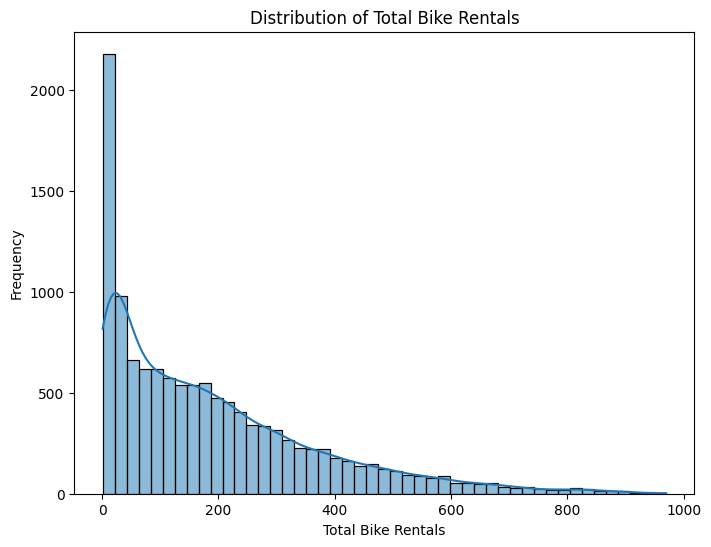

Skewness of 'cnt': 1.2677230274820341
Kurtosis of 'cnt': 1.3819006371434956


In [14]:
# Explore the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.histplot(df['cnt'], kde=True)
plt.title('Distribution of Total Bike Rentals')
plt.xlabel('Total Bike Rentals')
plt.ylabel('Frequency')
plt.show()


print(f"Skewness of 'cnt': {df['cnt'].skew()}")
print(f"Kurtosis of 'cnt': {df['cnt'].kurt()}")

Berdasarkan histogram plot, distribusi sepeda yang disewakan diatas terlihat bahwa terdapat *right-skewed distribution* dimana *skewness* positif pada fitur cnt (Target)

### **Distribusi Cuaca**

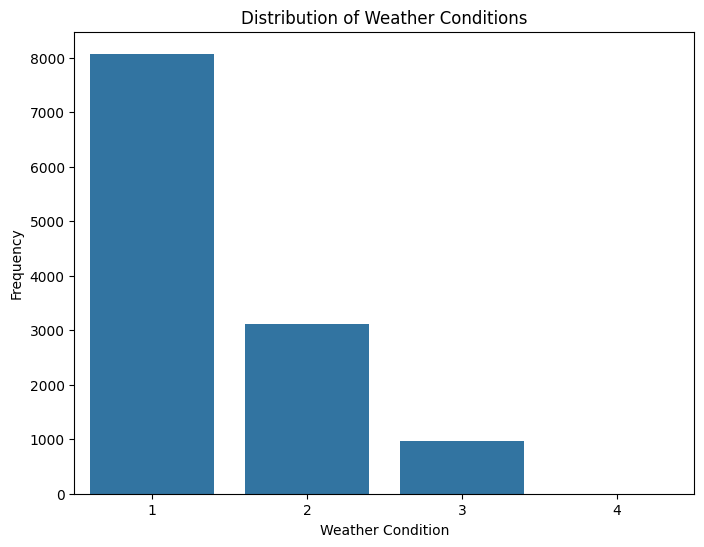

In [15]:
# Distribution of weather
plt.figure(figsize=(8, 6))
sns.countplot(x='weathersit', data=df)
plt.title('Distribution of Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Frequency')
plt.show()

Dapat dilihat dari visualisasi diatas bahwa total rental sepeda didominasi pada cuaca cerah, diikuti dengan cuaca berawan lalu salju tipis atau gerimis. Saat cuaca hujan deras atau salju lebat, tidak ada rental sepeda.

### **Distribusi Holiday**

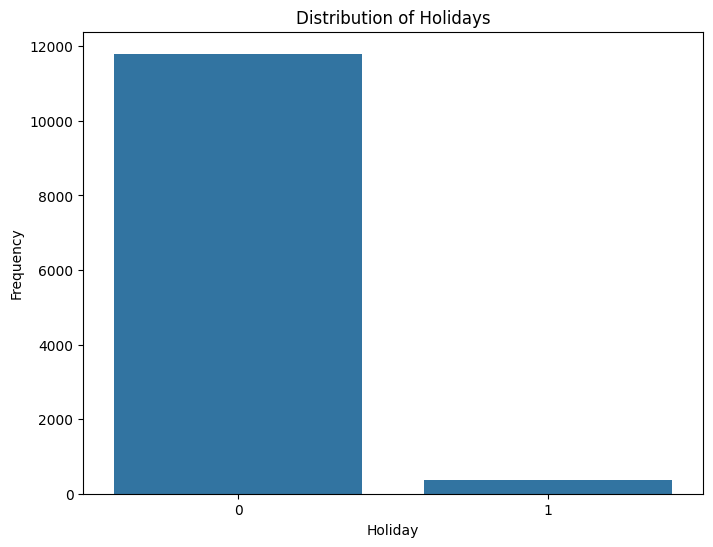

In [16]:
# Distribution of Holiday
plt.figure(figsize=(8, 6))
sns.countplot(x='holiday', data=df)
plt.title('Distribution of Holidays')
plt.xlabel('Holiday')
plt.ylabel('Frequency')
plt.show()

Dilihat dari visualisasi, mayoritas rental sepeda didominasi oleh not holiday. Pelanggan lebih banyak memakai layanan ketika hari kerja (non holiday) untuk penggunaan moda transportasi harian.

### **Distribusi dari Casual Users**

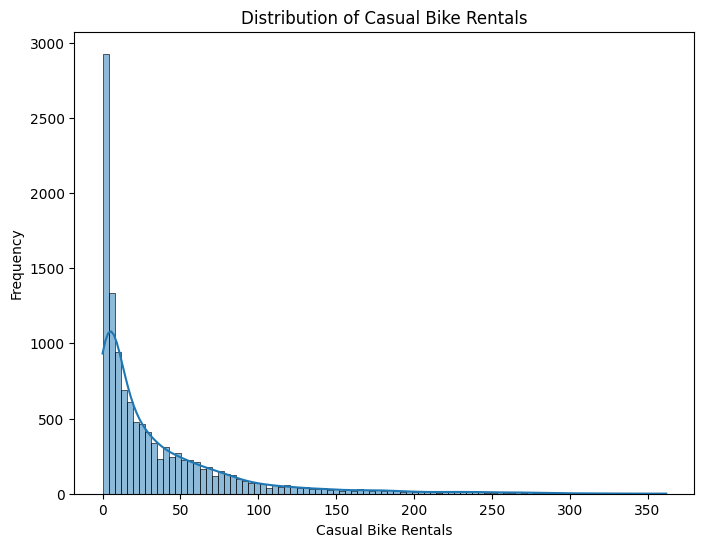

In [17]:
# Plot the distribution of casual users
plt.figure(figsize=(8, 6))
sns.histplot(df['casual'], kde=True)
plt.title('Distribution of Casual Bike Rentals')
plt.xlabel('Casual Bike Rentals')
plt.ylabel('Frequency')
plt.show()

Distribusi penyewaan sepeda kasual sangat condong ke kanan, dengan mayoritas hari memiliki penyewaan rendah, tetapi terdapat beberapa hari dengan permintaan tinggi sebagai outlier.

### **Distribusi dari Registered Users**

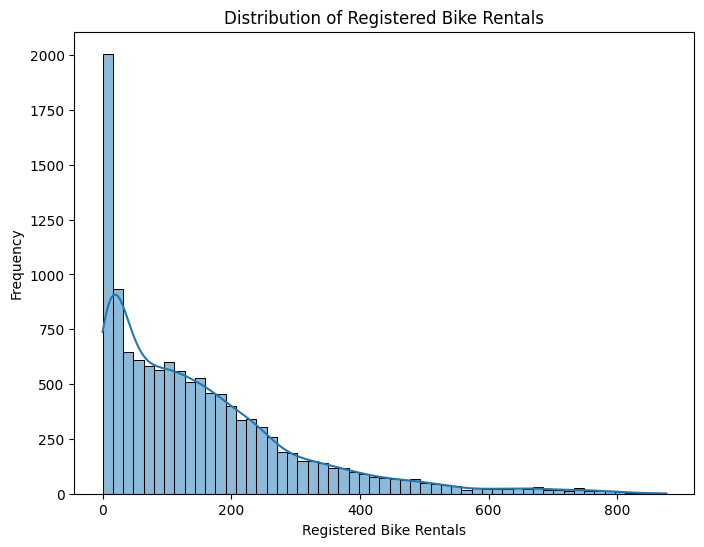

In [18]:
# Distribution of Registered user
plt.figure(figsize=(8, 6))
sns.histplot(df['registered'], kde=True)
plt.title('Distribution of Registered Bike Rentals')
plt.xlabel('Registered Bike Rentals')
plt.ylabel('Frequency')
plt.show()

Histogram menunjukkan distribusi tidak normal dari jumlah sewa sepeda terdaftar, dengan sebagian besar pendaftar memiliki jumlah sewa sedikit dan beberapa pendaftar memiliki jumlah sewa sangat besar.

### **Distribusi Temperatur**

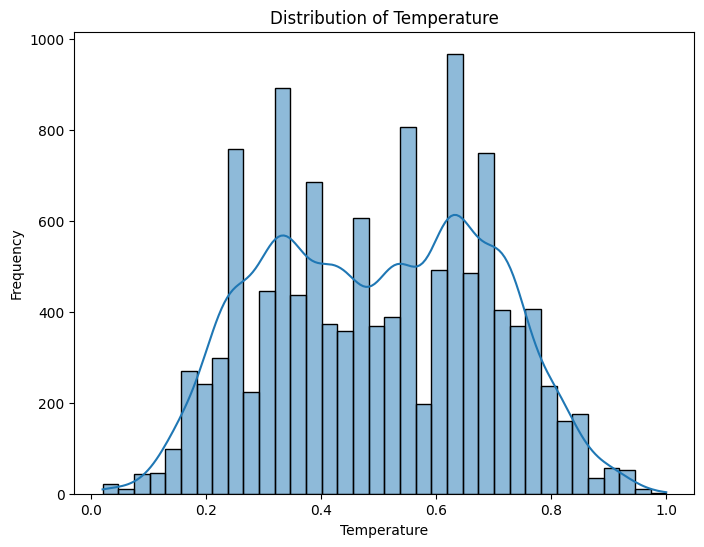

In [19]:
# distribution of temp
plt.figure(figsize=(8, 6))
sns.histplot(df['temp'], kde=True)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

### **Distribusi total rental berdasarkan Casual dan Registered Users**

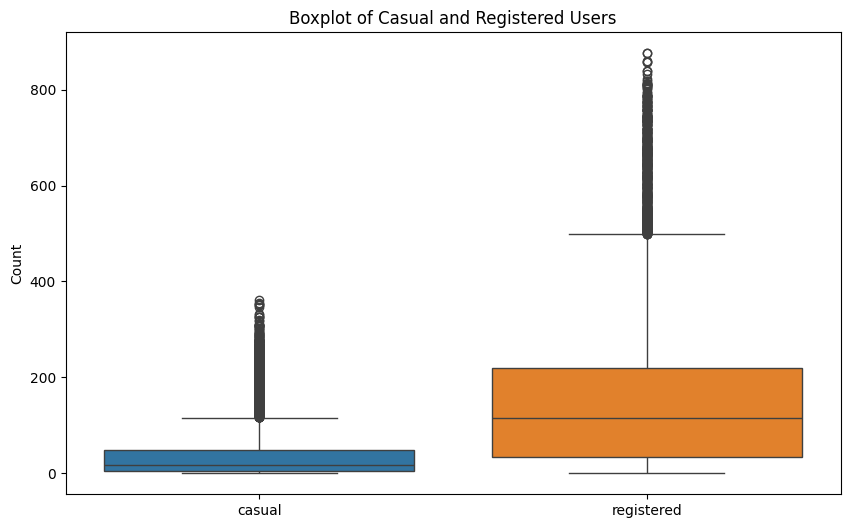

In [20]:
# boxplot for casual and registered column
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['casual', 'registered']])
plt.title('Boxplot of Casual and Registered Users')
plt.ylabel('Count')
plt.show()

### **Trendline count berdasarkan jam**

Text(0, 0.5, 'Total Bike Rentals')

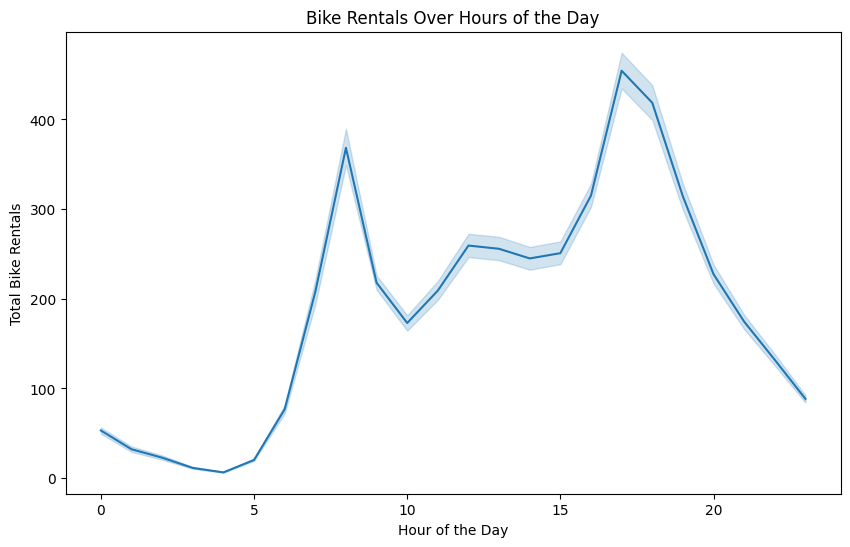

In [21]:
# Lineplot for hr and cnt
plt.figure(figsize=(10, 6))
sns.lineplot(x='hr', y='cnt', data=df)
plt.title('Bike Rentals Over Hours of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Bike Rentals')

### **Heatmap Correlation**

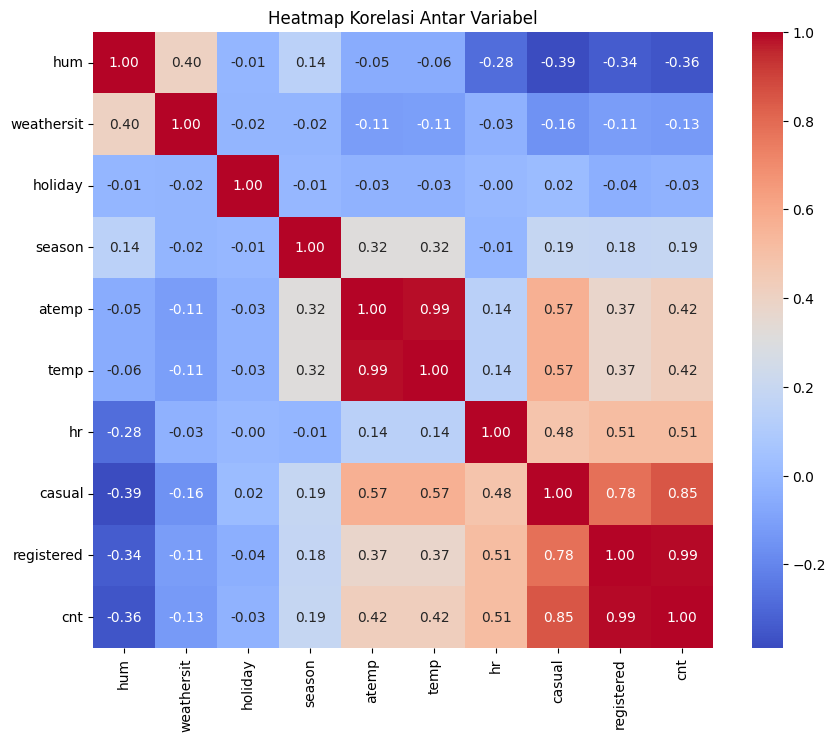

In [22]:
# Heatmap Correlation
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

Kesimpulan Awal:

- Variabel seperti temp dan hr kemungkinan memiliki korelasi positif terhadap cnt.
- Variabel hum memiliki korelasi negatif terhadap cnt.
- Pola musiman dan waktu (seperti jam sibuk) tampaknya memengaruhi jumlah peminjaman.

# **Data Preprocessing**

Pada tahap ini, kita akan melakukan cleaning pada data yang nantinya data yang sudah dibersihkan akan kita gunakan untuk proses analisis selanjutnya. Beberapa hal yang perlu dilakukan adalah:

- Mengganti beberapa nama kolom dan nilai tiap baris agar lebih intuitif (mudah terbaca)
- Mengubah tipe data pada kolom agar sesuai dengan nilai (value) yang dimiliki
- Cek missing value dan duplicated
- Drop feature yang tidak memiliki relevansi terhadap business problem
- Cek korelasi antar data
- cek outliers pada data numerik

**Menghapus kolom casual dan registered karena yang kita fokuskan adalah count (total rental)**

In [23]:
# Drop the casual and registered columns
df.drop(['casual', 'registered'], axis=1, inplace=True)

**Mengurutkan dataframe berdasarkan dteday dan hour**

In [24]:
# mengurutkan df by date and hour
df = df.sort_values(by=['dteday', 'hr']).reset_index(drop=True)

**mengubah nama kolom agar memudahkan keterbacaan**

In [25]:
# mengubah beberapa nama kolom
df = df.rename(columns={
    'dteday': 'date',
    'hum': 'humidity',
    'weathersit': 'weather',
    'temp': 'temperature',
    'hr': 'hour',
    'cnt': 'total_rentals'
})

In [26]:
df.head()

,date,humidity,weather,holiday,season,atemp,temperature,hour,total_rentals
0,2011-01-01,0.81,1,0,1,0.2879,0.24,0,16
1,2011-01-01,0.80,1,0,1,0.2727,0.22,1,40
2,2011-01-01,0.80,1,0,1,0.2727,0.22,2,32
3,2011-01-01,0.75,1,0,1,0.2879,0.24,3,13
4,2011-01-01,0.75,1,0,1,0.2879,0.24,4,1


**Mengubah tipe data 'date' dari object menjadi datetime**

In [27]:
# Mengubah tipe data 'date' dari object menjadi datetime
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           12165 non-null  datetime64[ns]
 1   humidity       12165 non-null  float64       
 2   weather        12165 non-null  int64         
 3   holiday        12165 non-null  int64         
 4   season         12165 non-null  int64         
 5   atemp          12165 non-null  float64       
 6   temperature    12165 non-null  float64       
 7   hour           12165 non-null  int64         
 8   total_rentals  12165 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(5)
memory usage: 855.5 KB


**Membuat kolom untuk memisahkan tahun, bulan, dan hari dari kolom date**

In [28]:
# Membuat kolom untuk memisahkan tahun, bulan, dan hari dari date
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day_name()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           12165 non-null  datetime64[ns]
 1   humidity       12165 non-null  float64       
 2   weather        12165 non-null  int64         
 3   holiday        12165 non-null  int64         
 4   season         12165 non-null  int64         
 5   atemp          12165 non-null  float64       
 6   temperature    12165 non-null  float64       
 7   hour           12165 non-null  int64         
 8   total_rentals  12165 non-null  int64         
 9   year           12165 non-null  int32         
 10  month          12165 non-null  int32         
 11  day            12165 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(2), int64(5), object(1)
memory usage: 1.0+ MB


**Mengubah tipe data kolom year, month, dan day ke kategori**

In [30]:
# change year, month, and day to category
df['year'] = df['year'].astype('category')
df['month'] = df['month'].astype('category')
df['day'] = df['day'].astype('category')

**Mengubah nilai baris di kolom month ke nama bulan**

In [31]:
# change value in month to month name

# Create a dictionary to map month numbers to month names
month_dict = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Use the map function to replace month numbers with month names
df['month'] = df['month'].map(month_dict)

**Mengubah nilai baris di kolom weather sesuai dengan deskripsi dataset**

In [32]:
# Create a dictionary to map weather categories to descriptive labels
weather_dict = {
    1: 'Clear/Partly Cloudy',
    2: 'Cloudy/Misty',
    3: 'Light Rain/Light Snow',
    4: 'Heavy Rain/Heavy Snow'
}

# Use the map function to replace numerical weather codes with descriptive labels
df['weather'] = df['weather'].map(weather_dict)

df.head()

,date,humidity,weather,holiday,season,atemp,temperature,hour,total_rentals,year,month,day
0,2011-01-01,0.81,Clear/Partly Cloudy,0,1,0.2879,0.24,0,16,2011,January,Saturday
1,2011-01-01,0.80,Clear/Partly Cloudy,0,1,0.2727,0.22,1,40,2011,January,Saturday
2,2011-01-01,0.80,Clear/Partly Cloudy,0,1,0.2727,0.22,2,32,2011,January,Saturday
3,2011-01-01,0.75,Clear/Partly Cloudy,0,1,0.2879,0.24,3,13,2011,January,Saturday
4,2011-01-01,0.75,Clear/Partly Cloudy,0,1,0.2879,0.24,4,1,2011,January,Saturday


In [33]:
# change weather dtype to category
df['weather'] = df['weather'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           12165 non-null  datetime64[ns]
 1   humidity       12165 non-null  float64       
 2   weather        12165 non-null  category      
 3   holiday        12165 non-null  int64         
 4   season         12165 non-null  int64         
 5   atemp          12165 non-null  float64       
 6   temperature    12165 non-null  float64       
 7   hour           12165 non-null  int64         
 8   total_rentals  12165 non-null  int64         
 9   year           12165 non-null  category      
 10  month          12165 non-null  category      
 11  day            12165 non-null  category      
dtypes: category(4), datetime64[ns](1), float64(3), int64(4)
memory usage: 809.0 KB


**Mengubah baris nilai pada kolom season menjadi data kategorikal sesuai dengan deskripsi dataset**

In [34]:
# change data season to categorical data

# Create a dictionary to map season categories to descriptive labels
season_dict = {
    1: 'Winter',
    2: 'Spring',
    3: 'Summer',
    4: 'Fall'
}

# Use the map function to replace numerical season codes with descriptive labels
df['season'] = df['season'].map(season_dict)

df.head()

,date,humidity,weather,holiday,season,atemp,temperature,hour,total_rentals,year,month,day
0,2011-01-01,0.81,Clear/Partly Cloudy,0,Winter,0.2879,0.24,0,16,2011,January,Saturday
1,2011-01-01,0.80,Clear/Partly Cloudy,0,Winter,0.2727,0.22,1,40,2011,January,Saturday
2,2011-01-01,0.80,Clear/Partly Cloudy,0,Winter,0.2727,0.22,2,32,2011,January,Saturday
3,2011-01-01,0.75,Clear/Partly Cloudy,0,Winter,0.2879,0.24,3,13,2011,January,Saturday
4,2011-01-01,0.75,Clear/Partly Cloudy,0,Winter,0.2879,0.24,4,1,2011,January,Saturday


In [35]:
# change season dtype to category
df['season'] = df['season'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           12165 non-null  datetime64[ns]
 1   humidity       12165 non-null  float64       
 2   weather        12165 non-null  category      
 3   holiday        12165 non-null  int64         
 4   season         12165 non-null  category      
 5   atemp          12165 non-null  float64       
 6   temperature    12165 non-null  float64       
 7   hour           12165 non-null  int64         
 8   total_rentals  12165 non-null  int64         
 9   year           12165 non-null  category      
 10  month          12165 non-null  category      
 11  day            12165 non-null  category      
dtypes: category(5), datetime64[ns](1), float64(3), int64(3)
memory usage: 726.0 KB


**Mengubah tipe data pada kolom holiday ke kategorikal**

In [36]:
# change column holiday to category
df['holiday'] = df['holiday'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           12165 non-null  datetime64[ns]
 1   humidity       12165 non-null  float64       
 2   weather        12165 non-null  category      
 3   holiday        12165 non-null  category      
 4   season         12165 non-null  category      
 5   atemp          12165 non-null  float64       
 6   temperature    12165 non-null  float64       
 7   hour           12165 non-null  int64         
 8   total_rentals  12165 non-null  int64         
 9   year           12165 non-null  category      
 10  month          12165 non-null  category      
 11  day            12165 non-null  category      
dtypes: category(6), datetime64[ns](1), float64(3), int64(2)
memory usage: 643.0 KB


**Mengubah baris data pada kolom holiday menjadi 'yes' dan 'no'**

In [37]:
# change holiday value to yes and no
df['holiday'] = df['holiday'].map({0: 'No', 1: 'Yes'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           12165 non-null  datetime64[ns]
 1   humidity       12165 non-null  float64       
 2   weather        12165 non-null  category      
 3   holiday        12165 non-null  category      
 4   season         12165 non-null  category      
 5   atemp          12165 non-null  float64       
 6   temperature    12165 non-null  float64       
 7   hour           12165 non-null  int64         
 8   total_rentals  12165 non-null  int64         
 9   year           12165 non-null  category      
 10  month          12165 non-null  category      
 11  day            12165 non-null  category      
dtypes: category(6), datetime64[ns](1), float64(3), int64(2)
memory usage: 643.0 KB


In [38]:
# Cek info lebih detail untuk setiap fitur
listItem = []

for col in df.columns:
    listItem.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col]))*100, 2),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

df_desc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                       data=listItem)
df_desc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,date,datetime64[ns],0,0.0,731,"[2011-09-06T00:00:00.000000000, 2012-12-05T00:..."
1,humidity,float64,0,0.0,89,"[0.29, 0.1]"
2,weather,category,0,0.0,4,"[Cloudy/Misty, Light Rain/Light Snow]"
3,holiday,category,0,0.0,2,"[Yes, No]"
4,season,category,0,0.0,4,"[Spring, Fall]"
5,atemp,float64,0,0.0,65,"[0.7727, 0.1667]"
6,temperature,float64,0,0.0,50,"[0.16, 0.22]"
7,hour,int64,0,0.0,24,"[5, 21]"
8,total_rentals,int64,0,0.0,830,"[133, 6]"
9,year,category,0,0.0,2,"[2012, 2011]"


Dari info dataset diatas, tidak terdapat missing value.

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.head()

,date,humidity,weather,holiday,season,atemp,temperature,hour,total_rentals,year,month,day
0,2011-01-01,0.81,Clear/Partly Cloudy,No,Winter,0.2879,0.24,0,16,2011,January,Saturday
1,2011-01-01,0.80,Clear/Partly Cloudy,No,Winter,0.2727,0.22,1,40,2011,January,Saturday
2,2011-01-01,0.80,Clear/Partly Cloudy,No,Winter,0.2727,0.22,2,32,2011,January,Saturday
3,2011-01-01,0.75,Clear/Partly Cloudy,No,Winter,0.2879,0.24,3,13,2011,January,Saturday
4,2011-01-01,0.75,Clear/Partly Cloudy,No,Winter,0.2879,0.24,4,1,2011,January,Saturday


## **Uji Hipotesis**

In [41]:
# Uji Hipotesis Data Kategori

# import wilcoxon dan kruskal
from scipy.stats import mannwhitneyu, kruskal

In [42]:
# Uji Hipotesis kolom 'total_rentals' terhadap kolom 'holiday'
# H0: Tidak ada perbedaan jumlah total rentals antara hari libur dan bukan hari libur
# H1: Ada perbedaan jumlah total rentals antara hari libur dan bukan hari libur

stat, pvalue = mannwhitneyu(df.loc[df['holiday'] == 'Yes', 'total_rentals'],
                            df.loc[df['holiday'] == 'No', 'total_rentals'])

if pvalue <= 0.05:
    print(f'P-Value: {pvalue}. Reject the null hypothesis')
else:
    print(f'P-Value: {pvalue}. Fail to reject the null hypothesis')

P-Value: 0.0012391359794333625. Reject the null hypothesis


Berdasarkan uji hipotesis, terdapat perbedaan total rentals antara hari libur dan bukan hari libur

In [43]:
# Year terhadap total_rental
# H0: Tidak ada perbedaan jumlah total rentals antara tahun 2011 dan 2012
# H1: Ada perbedaan jumlah total rentals antara tahun 2011 dan 2012
stat, pvalue = mannwhitneyu(df.loc[df['year'] == 2011, 'total_rentals'],
                            df.loc[df['year'] == 2012, 'total_rentals'])
if pvalue <= 0.05:
    print(f'P-Value: {pvalue}. Reject the null hypothesis')
else:
    print(f'P-Value: {pvalue}. Fail to reject the null hypothesis')

P-Value: 5.4243892419814e-108. Reject the null hypothesis


Berdasarkan hasil hipotesis, maka dapat disimpulkan bahwa terdapat perbedaan yang signifikan dalam nilai total_rental antara tahun 2011 dan 2012.

In [44]:
# month terhadap total_rental
# H0: Tidak ada perbedaan jumlah total rentals antara bulan Januari sampai Desember
# H1: Ada perbedaan jumlah total rentals antara bulan Januari sampai Desember
stat, pvalue = kruskal(*[df.loc[df['month'] == month, 'total_rentals'] for month in df['month'].unique()])

if pvalue <= 0.05:
    print(f'P-Value: {pvalue}. Reject the null hypothesis')
else:
    print(f'P-Value: {pvalue}. Fail to reject the null hypothesis')

P-Value: 7.212794070628948e-194. Reject the null hypothesis


Berdasarkan uji hipotesis, ada perbedaan signifikan dari total rental antara bulan Januari sampai Desember.

In [45]:
# day terhadap total rental
# H0: Tidak ada perbedaan jumlah total rentals antara hari Senin sampai Minggu
# H1: Ada perbedaan jumlah total rentals antara hari Senin sampai Minggu

stat, pvalue = kruskal(*[df.loc[df['day'] == day, 'total_rentals'] for day in df['day'].unique()])
if pvalue <= 0.05:
    print(f'P-Value: {pvalue}. Reject the null hypothesis')
else:
    print(f'P-Value: {pvalue}. Fail to reject the null hypothesis')

P-Value: 0.052910774550853565. Fail to reject the null hypothesis


Berdasarkan hasil uji hipotesis, tidak ada perbedaan total rental antara hari Senin sampai Minggu.

In [46]:
# weather terhadap total rental
# H0: Tidak ada perbedaan jumlah total rentals antara cuaca Clear/Partly Cloudy, Cloudy/Misty, Light Rain/Light Snow, dan Heavy Rain/Heavy Snow
# H1: Ada perbedaan jumlah total rentals antara cuaca Clear/Partly Cloudy, Cloudy/Misty, Light Rain/Light Snow, dan Heavy Rain/Heavy Snow

stat, pvalue = kruskal(*[df.loc[df['weather'] == weather, 'total_rentals'] for weather in df['weather'].unique()])

if pvalue <= 0.05:
    print(f'P-Value: {pvalue}. Reject the null hypothesis')
else:
    print(f'P-Value: {pvalue}. Fail to reject the null hypothesis')

P-Value: 3.0713883744120426e-52. Reject the null hypothesis


Berdasarkan uji hipotesis, ada perbedaan signifikan pada total rental antara cuaca

## **Feature Selection (Drop Column)**

- kolom date sudah tidak diperlukan karena sudah diwakilkan dengan kolom Year, Month, and Day
- kolom temperature dihapus, kita pakai atemp

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           12165 non-null  datetime64[ns]
 1   humidity       12165 non-null  float64       
 2   weather        12165 non-null  category      
 3   holiday        12165 non-null  category      
 4   season         12165 non-null  category      
 5   atemp          12165 non-null  float64       
 6   temperature    12165 non-null  float64       
 7   hour           12165 non-null  int64         
 8   total_rentals  12165 non-null  int64         
 9   year           12165 non-null  category      
 10  month          12165 non-null  category      
 11  day            12165 non-null  category      
dtypes: category(6), datetime64[ns](1), float64(3), int64(2)
memory usage: 643.0 KB


**Menghapus kolom date dan temperature**

In [48]:
# drop kolom (feature) yang tidak diperlukan
df.drop(columns=['date', 'temperature'], inplace=True)
df.head()

,humidity,weather,holiday,season,atemp,hour,total_rentals,year,month,day
0,0.81,Clear/Partly Cloudy,No,Winter,0.2879,0,16,2011,January,Saturday
1,0.80,Clear/Partly Cloudy,No,Winter,0.2727,1,40,2011,January,Saturday
2,0.80,Clear/Partly Cloudy,No,Winter,0.2727,2,32,2011,January,Saturday
3,0.75,Clear/Partly Cloudy,No,Winter,0.2879,3,13,2011,January,Saturday
4,0.75,Clear/Partly Cloudy,No,Winter,0.2879,4,1,2011,January,Saturday


**Cek Outliers**

In [49]:
df.describe()

,humidity,atemp,hour,total_rentals
count,12165.000000,12165.000000,12165.000000,12165.000000
mean,0.625451,0.476996,11.519770,189.271023
std,0.192102,0.171857,6.931872,181.223903
min,0.000000,0.000000,0.000000,1.000000
25%,0.470000,0.333300,6.000000,40.000000
50%,0.620000,0.484800,12.000000,142.000000
75%,0.780000,0.621200,18.000000,282.000000
max,1.000000,1.000000,23.000000,970.000000


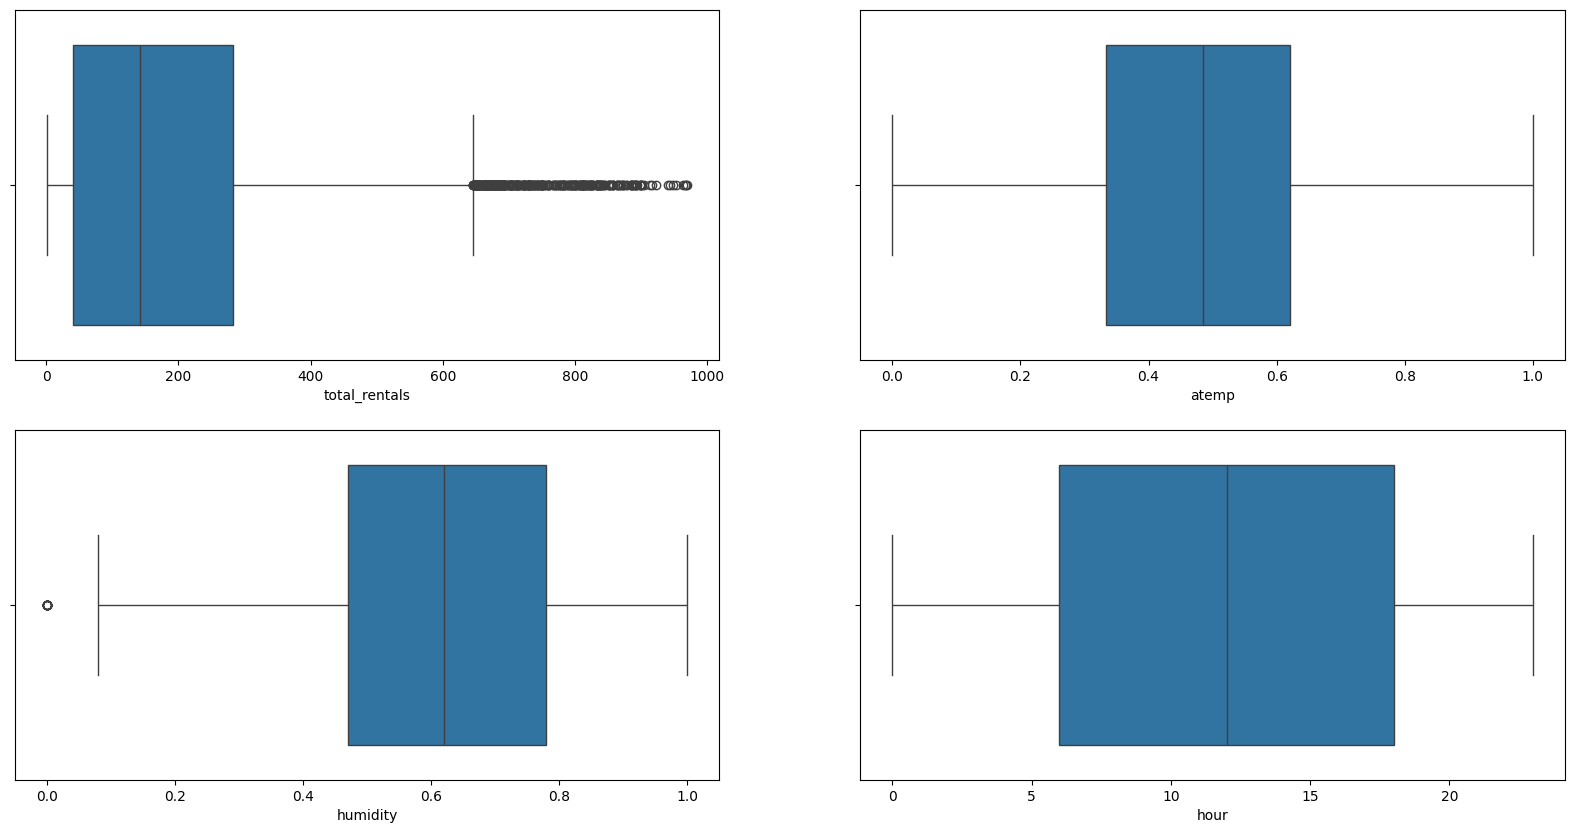

In [50]:
# boxplot for cek outlier
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
sns.boxplot(x='total_rentals', data=df, ax=ax[0, 0])
sns.boxplot(x='atemp', data=df, ax=ax[0, 1])
sns.boxplot(x='humidity', data=df, ax=ax[1, 0])
sns.boxplot(x='hour', data=df, ax=ax[1, 1])
plt.show()

In [51]:
df[df['humidity']==0]

,humidity,weather,holiday,season,atemp,hour,total_rentals,year,month,day
1094,0.0,Light Rain/Light Snow,No,Winter,0.3182,0,3,2011,March,Thursday
1095,0.0,Light Rain/Light Snow,No,Winter,0.3182,1,2,2011,March,Thursday
1096,0.0,Light Rain/Light Snow,No,Winter,0.3333,6,12,2011,March,Thursday
1097,0.0,Light Rain/Light Snow,No,Winter,0.3939,7,37,2011,March,Thursday
1098,0.0,Light Rain/Light Snow,No,Winter,0.3939,8,44,2011,March,Thursday
1099,0.0,Light Rain/Light Snow,No,Winter,0.4091,9,24,2011,March,Thursday
1100,0.0,Light Rain/Light Snow,No,Winter,0.4091,11,11,2011,March,Thursday
1101,0.0,Light Rain/Light Snow,No,Winter,0.4242,12,34,2011,March,Thursday
1102,0.0,Light Rain/Light Snow,No,Winter,0.4242,13,12,2011,March,Thursday
1103,0.0,Light Rain/Light Snow,No,Winter,0.4394,15,14,2011,March,Thursday


Melansir dari website [WGNTV](https://wgntv.com/weather/can-the-relative-humidity-ever-be-zero-percent/#:~:text=The%20concept%20of%20zero%20percent,if%20only%20in%20trace%20amounts), nilai humidity relatif tidak mungkin bernilai 0. Uap air akan selalu ada di udara, bahkan jika jumlahnya hanya sedikit.

In [52]:
# Filter the dataframe based on the specified conditions
filtered_df = df[(df['weather'] == 'Light Rain/Light Snow') & 
                 (df['season'] == 'Winter') &  
                 (df['month'] == 'March') &
                 (df['year'] == 2011)]

# Display the filtered dataframe
filtered_df.sort_values(by='humidity', ascending=True).head(20)

,humidity,weather,holiday,season,atemp,hour,total_rentals,year,month,day
1096,0.00,Light Rain/Light Snow,No,Winter,0.3333,6,12,2011,March,Thursday
1097,0.00,Light Rain/Light Snow,No,Winter,0.3939,7,37,2011,March,Thursday
1099,0.00,Light Rain/Light Snow,No,Winter,0.4091,9,24,2011,March,Thursday
1098,0.00,Light Rain/Light Snow,No,Winter,0.3939,8,44,2011,March,Thursday
1094,0.00,Light Rain/Light Snow,No,Winter,0.3182,0,3,2011,March,Thursday
1095,0.00,Light Rain/Light Snow,No,Winter,0.3182,1,2,2011,March,Thursday
1101,0.00,Light Rain/Light Snow,No,Winter,0.4242,12,34,2011,March,Thursday
1100,0.00,Light Rain/Light Snow,No,Winter,0.4091,11,11,2011,March,Thursday
1103,0.00,Light Rain/Light Snow,No,Winter,0.4394,15,14,2011,March,Thursday
1102,0.00,Light Rain/Light Snow,No,Winter,0.4242,13,12,2011,March,Thursday


In [53]:
filtered_df.describe()

,humidity,atemp,hour,total_rentals
count,28.000000,28.000000,28.000000,28.000000
mean,0.540714,0.342521,11.678571,18.071429
std,0.483099,0.070623,8.078566,13.882919
min,0.000000,0.181800,0.000000,2.000000
25%,0.000000,0.303000,5.000000,7.750000
50%,0.870000,0.333300,12.500000,13.000000
75%,1.000000,0.409100,18.250000,24.250000
max,1.000000,0.439400,23.000000,55.000000


**Mengganti nilai 0.0 dengan nilai mean humidity dari groupby yang telah dilakukan**

In [54]:
df['humidity'] = df['humidity'].replace(0, 0.54)

In [55]:
df[df['humidity']==0]

,humidity,weather,holiday,season,atemp,hour,total_rentals,year,month,day


**Correlation Matrix**

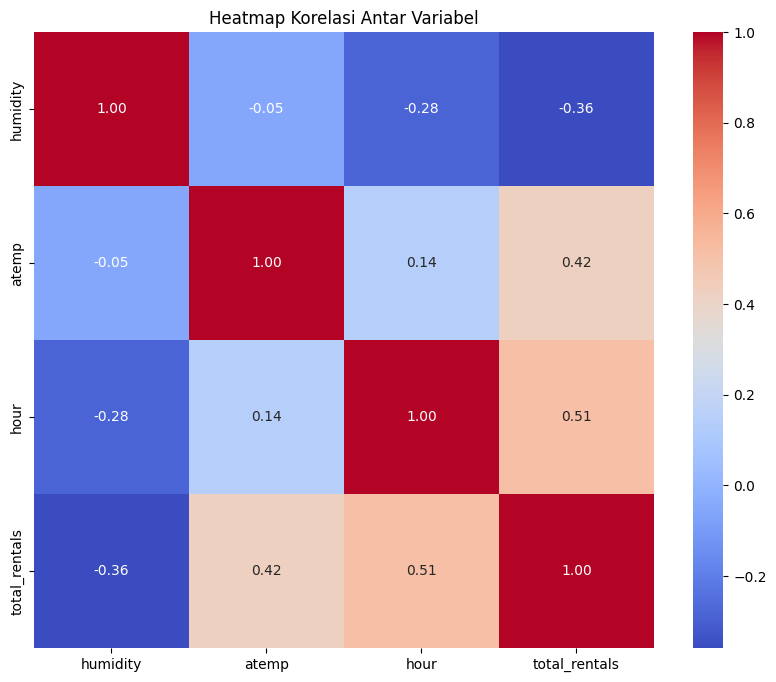

In [56]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

**Penjelasan Matrix Korelasi Pada Variabel Numerik**
Interval Koefisien|Status Hubungan|
|-----|-----|
|0.7 sampai 1|Hubungan positif kuat|
|0.3 sampai 0.7|Hubungan positif moderat|
|0.0 sampai 0.3|Hubungan positif lemah|
|0.0 sampai -0.3|Hubungan negatif lemah|
|-0.3 sampai -0.7|Hubungan negatif moderat|
|-0.7 ssampai -1|Hubungan negatif kuat

**Sumber:** Koefisien Korelasi Pearson

# **Modelling**

In [57]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Column Transformer
from sklearn.compose import ColumnTransformer

# Pipeline
from sklearn.pipeline import Pipeline

# Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

# cross validation
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, StackingRegressor, VotingRegressor, BaggingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

# Metrics Evaluation
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tools.eval_measures import rmse

# **Define X and y**

- X: merupakan sebuah DataFrame yang berisi feature atau variabel independent yang akan digunakan untuk memprediksi nilai target (variabel dependent)
- y: merupakan sebuah DataFrame yang berisi nilai target (variabel dependent) yang akan diprediksi oleh model.

In [58]:
X = df.drop(columns=['total_rentals'])
y = df['total_rentals']

display(X.head(), y.head())

,humidity,weather,holiday,season,atemp,hour,year,month,day
0,0.81,Clear/Partly Cloudy,No,Winter,0.2879,0,2011,January,Saturday
1,0.80,Clear/Partly Cloudy,No,Winter,0.2727,1,2011,January,Saturday
2,0.80,Clear/Partly Cloudy,No,Winter,0.2727,2,2011,January,Saturday
3,0.75,Clear/Partly Cloudy,No,Winter,0.2879,3,2011,January,Saturday
4,0.75,Clear/Partly Cloudy,No,Winter,0.2879,4,2011,January,Saturday


0    16
1    40
2    32
3    13
4     1
Name: total_rentals, dtype: int64

# **Train Test Split**

- Fungsi train_test_split digunakan untuk membagi data menjadi set pelatihan dan pengujian. Fungsi ini berguna dalam pembelajaran mesin untuk membangun model dan mengevaluasi keakuratannya. 

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Preprocessing**

- Encoding:
  - OneHotEncoder: weather, season, year, holiday
  - binary: month, day
- Scaling:
  - RobustScaler: humidity, atemp, hour

In [60]:
X_train

,humidity,weather,holiday,season,atemp,hour,year,month,day
10288,0.52,Clear/Partly Cloudy,No,Summer,0.5303,23,2012,September,Sunday
5587,0.75,Clear/Partly Cloudy,No,Fall,0.3182,3,2011,December,Sunday
4147,0.74,Cloudy/Misty,Yes,Summer,0.6667,11,2011,September,Monday
5257,0.28,Cloudy/Misty,No,Fall,0.5152,14,2011,November,Sunday
2628,0.89,Clear/Partly Cloudy,No,Spring,0.5909,0,2011,June,Wednesday
...,...,...,...,...,...,...,...,...,...
11964,0.65,Cloudy/Misty,No,Fall,0.3333,6,2012,December,Thursday
5191,0.93,Clear/Partly Cloudy,No,Fall,0.3636,9,2011,November,Wednesday
5390,0.87,Light Rain/Light Snow,No,Fall,0.4091,21,2011,November,Monday
860,0.26,Clear/Partly Cloudy,No,Winter,0.3333,18,2011,February,Wednesday


In [61]:
from category_encoders import BinaryEncoder

In [62]:
transformer = ColumnTransformer([
    ('encoder', OneHotEncoder(drop='first'), ['weather', 'season', 'year', 'holiday']),
    ('binary', BinaryEncoder(), ['month', 'day']),
    ('scaler', RobustScaler(), ['humidity', 'atemp', 'hour'])
], remainder='passthrough')
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('encoder', OneHotEncoder(drop='first'),
                                 ['weather', 'season', 'year', 'holiday']),
                                ('binary', BinaryEncoder(), ['month', 'day']),
                                ('scaler', RobustScaler(),
                                 ['humidity', 'atemp', 'hour'])])

**Model Benchmark**

In [63]:
# menentukan algoritma model benchmark
lr = LinearRegression()
ridge = Ridge()
lasso = Lasso()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()
gb = GradientBoostingRegressor()
xgb = XGBRegressor()
knn = KNeighborsRegressor()
stacking = StackingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('ridge', Ridge()),
        ('lasso', Lasso()),
        ('dt', DecisionTreeRegressor()),
        ('knn', KNeighborsRegressor()),
    ],
    final_estimator=LinearRegression()
)
voting = VotingRegressor(
    estimators=[
        ('lr', LinearRegression()),
        ('ridge', Ridge()),
        ('lasso', Lasso()),
        ('dt', DecisionTreeRegressor()),
        ('knn', KNeighborsRegressor()),
    ]
)
bagging = BaggingRegressor()

In [64]:
# get_scorer_names
from sklearn.metrics import get_scorer_names
get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

In [65]:
model = [lr, ridge, lasso, dt, rf, gb, xgb, knn, stacking, voting, bagging]

# rmse
list_score_rmse = []
list_mean_score_rmse = []
list_std_score_rmse = []

# mae
list_score_mae = []
list_mean_score_mae = []
list_std_score_mae = []

list_score_mape = []
list_mean_score_mape = []
list_std_score_mape = []

list_score_r2 = []
list_mean_score_r2 = []
list_std_score_r2 = []

# list scorer
list_scorer = ['neg_mean_absolute_error',
               'neg_mean_absolute_percentage_error',
               'neg_mean_squared_error',
               'r2']

# mencari model dari algoritma terbaik
for i in model:
  # pipeline_prep_model
  pipeline = Pipeline([
      ('prep', transformer),
      ('algo', i)
  ])

  scores = {} # Dictionary to store scores for each metric
  for scorer in list_scorer:
    # cross_val_score for each scorer
    cross_val = cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring=scorer, # Use a single scorer here
        cv=5,
        error_score='raise'
    )
    scores[scorer] = cross_val # Store scores in the dictionary
  
  # Append the scores to the respective lists

  # rmse
  list_score_rmse.append(scores['neg_mean_squared_error'])
  list_mean_score_rmse.append(scores['neg_mean_squared_error'].mean())
  list_std_score_rmse.append(scores['neg_mean_squared_error'].std())
  
  # mae
  list_score_mae.append(scores['neg_mean_absolute_error'])
  list_mean_score_mae.append(scores['neg_mean_absolute_error'].mean())
  list_std_score_mae.append(scores['neg_mean_absolute_error'].std())

  # mape
  list_score_mape.append(scores['neg_mean_absolute_percentage_error'])
  list_mean_score_mape.append(scores['neg_mean_absolute_percentage_error'].mean())
  list_std_score_mape.append(scores['neg_mean_absolute_percentage_error'].std())

  # r2
  list_score_r2.append(scores['r2'])
  list_mean_score_r2.append(scores['r2'].mean())
  list_std_score_r2.append(scores['r2'].std())

In [66]:
df_score = pd.DataFrame({
    'model': [str(m) for m in model], # Convert models to string representations
    'rmse': list_score_rmse, # Store the scores
    'mean_rmse': list_mean_score_rmse, # Use mean RMSE for sorting
    'std_rmse': list_std_score_rmse,
    'mae': list_score_mae, # Store the scores
    'mean_mae': list_mean_score_mae, # Use mean MAE for sorting
    'std_mae': list_std_score_mae,
    'mean_mape': list_mean_score_mape, # Use mean MAPE
    'std_mape': list_std_score_mape,
    'mean_r2': list_mean_score_r2, # Use mean R2
    'std_r2': list_std_score_r2
})

df_score

,model,rmse,mean_rmse,std_rmse,mae,mean_mae,std_mae,mean_mape,std_mape,mean_r2,std_r2
0,LinearRegression(),"[-19862.199810450726, -20135.473949977666, -21...",-20048.655844,698.190309,"[-105.8446835403121, -105.22481425829613, -109...",-106.259067,1.544935,-3.380224,0.123994,0.389245,0.009229
1,Ridge(),"[-19861.355429732936, -20136.363831607177, -21...",-20048.458195,697.943215,"[-105.8441069055255, -105.21735883633556, -109...",-106.255456,1.545632,-3.380048,0.123954,0.389251,0.009208
2,Lasso(),"[-19839.914136673586, -20366.93345479808, -213...",-20174.692048,670.682445,"[-105.17494509343209, -104.96661596240399, -10...",-105.924516,1.403400,-3.371709,0.132727,0.385409,0.006619
3,DecisionTreeRegressor(),"[-4779.151258346174, -4437.749357986646, -4757...",-4706.524034,266.572512,"[-41.67360041088855, -38.7663071391885, -40.75...",-40.685772,1.048169,-0.457806,0.038445,0.852270,0.012712
4,RandomForestRegressor(),"[-2874.5430200454143, -2407.2949506258246, -29...",-2727.027929,184.781216,"[-32.10381407293272, -30.7077614278377, -31.67...",-31.575899,0.463221,-0.391256,0.023946,0.916411,0.006260
5,GradientBoostingRegressor(),"[-7690.137196810326, -6073.276432697664, -6110...",-6292.539352,712.477824,"[-59.74637208081388, -52.98049298603293, -53.4...",-54.184756,2.870253,-0.956436,0.043487,0.807974,0.024579
6,"XGBRegressor(base_score=None, booster=None, ca...","[-2250.478515625, -1788.68212890625, -2238.330...",-2102.923828,167.019565,"[-30.4792423248291, -27.692520141601562, -29.3...",-29.187357,0.893527,-0.494723,0.024591,0.935823,0.005970
7,KNeighborsRegressor(),"[-17553.775100154086, -17605.22033898305, -185...",-17502.318442,673.427238,"[-93.20708782742682, -92.35192604006164, -94.5...",-92.633016,1.736476,-2.912615,0.351353,0.466835,0.011311
8,"StackingRegressor(estimators=[('lr', LinearReg...","[-4564.625289309423, -4053.2698510442738, -443...",-4349.040716,176.014062,"[-42.156546969041585, -40.27486797286614, -41....",-41.113284,0.630612,-0.670680,0.046588,0.868885,0.006557
9,"VotingRegressor(estimators=[('lr', LinearRegre...","[-12342.548518714857, -12414.966189658318, -13...",-12377.941564,435.826147,"[-82.57901759204215, -81.49054004048467, -84.6...",-82.407125,1.386671,-2.518283,0.152778,0.622268,0.006392


In [67]:
# from df_score, show 4 column only (just mean rmse, mean mae, mean mape, and mean r2)
df_score[['model','mean_rmse', 'mean_mae', 'mean_mape', 'mean_r2']].sort_values(by='mean_rmse', ascending=False)

,model,mean_rmse,mean_mae,mean_mape,mean_r2
6,"XGBRegressor(base_score=None, booster=None, ca...",-2102.923828,-29.187357,-0.494723,0.935823
4,RandomForestRegressor(),-2727.027929,-31.575899,-0.391256,0.916411
10,BaggingRegressor(),-3052.708101,-33.298832,-0.405223,0.911009
8,"StackingRegressor(estimators=[('lr', LinearReg...",-4349.040716,-41.113284,-0.670680,0.868885
3,DecisionTreeRegressor(),-4706.524034,-40.685772,-0.457806,0.852270
5,GradientBoostingRegressor(),-6292.539352,-54.184756,-0.956436,0.807974
9,"VotingRegressor(estimators=[('lr', LinearRegre...",-12377.941564,-82.407125,-2.518283,0.622268
7,KNeighborsRegressor(),-17502.318442,-92.633016,-2.912615,0.466835
1,Ridge(),-20048.458195,-106.255456,-3.380048,0.389251
0,LinearRegression(),-20048.655844,-106.259067,-3.380224,0.389245


In [68]:
# sort values by mean_rmse
df_score.sort_values(by='mean_rmse', ascending=False)

,model,rmse,mean_rmse,std_rmse,mae,mean_mae,std_mae,mean_mape,std_mape,mean_r2,std_r2
6,"XGBRegressor(base_score=None, booster=None, ca...","[-2250.478515625, -1788.68212890625, -2238.330...",-2102.923828,167.019565,"[-30.4792423248291, -27.692520141601562, -29.3...",-29.187357,0.893527,-0.494723,0.024591,0.935823,0.005970
4,RandomForestRegressor(),"[-2874.5430200454143, -2407.2949506258246, -29...",-2727.027929,184.781216,"[-32.10381407293272, -30.7077614278377, -31.67...",-31.575899,0.463221,-0.391256,0.023946,0.916411,0.006260
10,BaggingRegressor(),"[-3399.960269267447, -2682.2048746190726, -298...",-3052.708101,241.441911,"[-33.16742852251327, -32.189378531073444, -33....",-33.298832,0.611778,-0.405223,0.025554,0.911009,0.006184
8,"StackingRegressor(estimators=[('lr', LinearReg...","[-4564.625289309423, -4053.2698510442738, -443...",-4349.040716,176.014062,"[-42.156546969041585, -40.27486797286614, -41....",-41.113284,0.630612,-0.670680,0.046588,0.868885,0.006557
3,DecisionTreeRegressor(),"[-4779.151258346174, -4437.749357986646, -4757...",-4706.524034,266.572512,"[-41.67360041088855, -38.7663071391885, -40.75...",-40.685772,1.048169,-0.457806,0.038445,0.852270,0.012712
5,GradientBoostingRegressor(),"[-7690.137196810326, -6073.276432697664, -6110...",-6292.539352,712.477824,"[-59.74637208081388, -52.98049298603293, -53.4...",-54.184756,2.870253,-0.956436,0.043487,0.807974,0.024579
9,"VotingRegressor(estimators=[('lr', LinearRegre...","[-12342.548518714857, -12414.966189658318, -13...",-12377.941564,435.826147,"[-82.57901759204215, -81.49054004048467, -84.6...",-82.407125,1.386671,-2.518283,0.152778,0.622268,0.006392
7,KNeighborsRegressor(),"[-17553.775100154086, -17605.22033898305, -185...",-17502.318442,673.427238,"[-93.20708782742682, -92.35192604006164, -94.5...",-92.633016,1.736476,-2.912615,0.351353,0.466835,0.011311
1,Ridge(),"[-19861.355429732936, -20136.363831607177, -21...",-20048.458195,697.943215,"[-105.8441069055255, -105.21735883633556, -109...",-106.255456,1.545632,-3.380048,0.123954,0.389251,0.009208
0,LinearRegression(),"[-19862.199810450726, -20135.473949977666, -21...",-20048.655844,698.190309,"[-105.8446835403121, -105.22481425829613, -109...",-106.259067,1.544935,-3.380224,0.123994,0.389245,0.009229


In [69]:
# sort values by mean_mae
df_score.sort_values(by='mean_mae', ascending=False)

,model,rmse,mean_rmse,std_rmse,mae,mean_mae,std_mae,mean_mape,std_mape,mean_r2,std_r2
6,"XGBRegressor(base_score=None, booster=None, ca...","[-2250.478515625, -1788.68212890625, -2238.330...",-2102.923828,167.019565,"[-30.4792423248291, -27.692520141601562, -29.3...",-29.187357,0.893527,-0.494723,0.024591,0.935823,0.005970
4,RandomForestRegressor(),"[-2874.5430200454143, -2407.2949506258246, -29...",-2727.027929,184.781216,"[-32.10381407293272, -30.7077614278377, -31.67...",-31.575899,0.463221,-0.391256,0.023946,0.916411,0.006260
10,BaggingRegressor(),"[-3399.960269267447, -2682.2048746190726, -298...",-3052.708101,241.441911,"[-33.16742852251327, -32.189378531073444, -33....",-33.298832,0.611778,-0.405223,0.025554,0.911009,0.006184
3,DecisionTreeRegressor(),"[-4779.151258346174, -4437.749357986646, -4757...",-4706.524034,266.572512,"[-41.67360041088855, -38.7663071391885, -40.75...",-40.685772,1.048169,-0.457806,0.038445,0.852270,0.012712
8,"StackingRegressor(estimators=[('lr', LinearReg...","[-4564.625289309423, -4053.2698510442738, -443...",-4349.040716,176.014062,"[-42.156546969041585, -40.27486797286614, -41....",-41.113284,0.630612,-0.670680,0.046588,0.868885,0.006557
5,GradientBoostingRegressor(),"[-7690.137196810326, -6073.276432697664, -6110...",-6292.539352,712.477824,"[-59.74637208081388, -52.98049298603293, -53.4...",-54.184756,2.870253,-0.956436,0.043487,0.807974,0.024579
9,"VotingRegressor(estimators=[('lr', LinearRegre...","[-12342.548518714857, -12414.966189658318, -13...",-12377.941564,435.826147,"[-82.57901759204215, -81.49054004048467, -84.6...",-82.407125,1.386671,-2.518283,0.152778,0.622268,0.006392
7,KNeighborsRegressor(),"[-17553.775100154086, -17605.22033898305, -185...",-17502.318442,673.427238,"[-93.20708782742682, -92.35192604006164, -94.5...",-92.633016,1.736476,-2.912615,0.351353,0.466835,0.011311
2,Lasso(),"[-19839.914136673586, -20366.93345479808, -213...",-20174.692048,670.682445,"[-105.17494509343209, -104.96661596240399, -10...",-105.924516,1.403400,-3.371709,0.132727,0.385409,0.006619
1,Ridge(),"[-19861.355429732936, -20136.363831607177, -21...",-20048.458195,697.943215,"[-105.8441069055255, -105.21735883633556, -109...",-106.255456,1.545632,-3.380048,0.123954,0.389251,0.009208


In [70]:
# sort values by mean_mape
df_score.sort_values(by='mean_mape', ascending=False)

,model,rmse,mean_rmse,std_rmse,mae,mean_mae,std_mae,mean_mape,std_mape,mean_r2,std_r2
4,RandomForestRegressor(),"[-2874.5430200454143, -2407.2949506258246, -29...",-2727.027929,184.781216,"[-32.10381407293272, -30.7077614278377, -31.67...",-31.575899,0.463221,-0.391256,0.023946,0.916411,0.006260
10,BaggingRegressor(),"[-3399.960269267447, -2682.2048746190726, -298...",-3052.708101,241.441911,"[-33.16742852251327, -32.189378531073444, -33....",-33.298832,0.611778,-0.405223,0.025554,0.911009,0.006184
3,DecisionTreeRegressor(),"[-4779.151258346174, -4437.749357986646, -4757...",-4706.524034,266.572512,"[-41.67360041088855, -38.7663071391885, -40.75...",-40.685772,1.048169,-0.457806,0.038445,0.852270,0.012712
6,"XGBRegressor(base_score=None, booster=None, ca...","[-2250.478515625, -1788.68212890625, -2238.330...",-2102.923828,167.019565,"[-30.4792423248291, -27.692520141601562, -29.3...",-29.187357,0.893527,-0.494723,0.024591,0.935823,0.005970
8,"StackingRegressor(estimators=[('lr', LinearReg...","[-4564.625289309423, -4053.2698510442738, -443...",-4349.040716,176.014062,"[-42.156546969041585, -40.27486797286614, -41....",-41.113284,0.630612,-0.670680,0.046588,0.868885,0.006557
5,GradientBoostingRegressor(),"[-7690.137196810326, -6073.276432697664, -6110...",-6292.539352,712.477824,"[-59.74637208081388, -52.98049298603293, -53.4...",-54.184756,2.870253,-0.956436,0.043487,0.807974,0.024579
9,"VotingRegressor(estimators=[('lr', LinearRegre...","[-12342.548518714857, -12414.966189658318, -13...",-12377.941564,435.826147,"[-82.57901759204215, -81.49054004048467, -84.6...",-82.407125,1.386671,-2.518283,0.152778,0.622268,0.006392
7,KNeighborsRegressor(),"[-17553.775100154086, -17605.22033898305, -185...",-17502.318442,673.427238,"[-93.20708782742682, -92.35192604006164, -94.5...",-92.633016,1.736476,-2.912615,0.351353,0.466835,0.011311
2,Lasso(),"[-19839.914136673586, -20366.93345479808, -213...",-20174.692048,670.682445,"[-105.17494509343209, -104.96661596240399, -10...",-105.924516,1.403400,-3.371709,0.132727,0.385409,0.006619
1,Ridge(),"[-19861.355429732936, -20136.363831607177, -21...",-20048.458195,697.943215,"[-105.8441069055255, -105.21735883633556, -109...",-106.255456,1.545632,-3.380048,0.123954,0.389251,0.009208


In [71]:
# sort values by mean_r2
df_score.sort_values(by='mean_r2', ascending=False)

,model,rmse,mean_rmse,std_rmse,mae,mean_mae,std_mae,mean_mape,std_mape,mean_r2,std_r2
6,"XGBRegressor(base_score=None, booster=None, ca...","[-2250.478515625, -1788.68212890625, -2238.330...",-2102.923828,167.019565,"[-30.4792423248291, -27.692520141601562, -29.3...",-29.187357,0.893527,-0.494723,0.024591,0.935823,0.005970
4,RandomForestRegressor(),"[-2874.5430200454143, -2407.2949506258246, -29...",-2727.027929,184.781216,"[-32.10381407293272, -30.7077614278377, -31.67...",-31.575899,0.463221,-0.391256,0.023946,0.916411,0.006260
10,BaggingRegressor(),"[-3399.960269267447, -2682.2048746190726, -298...",-3052.708101,241.441911,"[-33.16742852251327, -32.189378531073444, -33....",-33.298832,0.611778,-0.405223,0.025554,0.911009,0.006184
8,"StackingRegressor(estimators=[('lr', LinearReg...","[-4564.625289309423, -4053.2698510442738, -443...",-4349.040716,176.014062,"[-42.156546969041585, -40.27486797286614, -41....",-41.113284,0.630612,-0.670680,0.046588,0.868885,0.006557
3,DecisionTreeRegressor(),"[-4779.151258346174, -4437.749357986646, -4757...",-4706.524034,266.572512,"[-41.67360041088855, -38.7663071391885, -40.75...",-40.685772,1.048169,-0.457806,0.038445,0.852270,0.012712
5,GradientBoostingRegressor(),"[-7690.137196810326, -6073.276432697664, -6110...",-6292.539352,712.477824,"[-59.74637208081388, -52.98049298603293, -53.4...",-54.184756,2.870253,-0.956436,0.043487,0.807974,0.024579
9,"VotingRegressor(estimators=[('lr', LinearRegre...","[-12342.548518714857, -12414.966189658318, -13...",-12377.941564,435.826147,"[-82.57901759204215, -81.49054004048467, -84.6...",-82.407125,1.386671,-2.518283,0.152778,0.622268,0.006392
7,KNeighborsRegressor(),"[-17553.775100154086, -17605.22033898305, -185...",-17502.318442,673.427238,"[-93.20708782742682, -92.35192604006164, -94.5...",-92.633016,1.736476,-2.912615,0.351353,0.466835,0.011311
1,Ridge(),"[-19861.355429732936, -20136.363831607177, -21...",-20048.458195,697.943215,"[-105.8441069055255, -105.21735883633556, -109...",-106.255456,1.545632,-3.380048,0.123954,0.389251,0.009208
0,LinearRegression(),"[-19862.199810450726, -20135.473949977666, -21...",-20048.655844,698.190309,"[-105.8446835403121, -105.22481425829613, -109...",-106.259067,1.544935,-3.380224,0.123994,0.389245,0.009229


**Kesimpulan:**
- Berdasarkan skor-skor pada model, model XGB menunjukkan performa terbaik. XGB memiliki nilai RMSE dan MAE terendah, menandakan error yang lebih kecil. Nilai R2 XGB juga paling tinggi, menandakan model ini dapat menjelaskan range varian data yang lebih luas.
- Meskipun RandomForest memiliki nilai MAPE terbesar, namun secara nilai absolut masih lebih tinggi dari XGB.

In [72]:
xgb = XGBRegressor()

score_rmse = []
score_mae = []
score_mape = []
score_r2 = []

# pipeline_prep_model
estimator = Pipeline([
    ('prep', transformer),
    ('algo', xgb)
])

estimator.fit(X_train, y_train)
y_pred = estimator.predict(X_test)
y_pred_train = estimator.predict(X_train)

# scoring
gb_test_rmse = rmse(y_test, y_pred)
gb_train_rmse = rmse(y_train, y_pred_train)

gb_test_mae = mean_absolute_error(y_test, y_pred)
gb_train_mae = mean_absolute_error(y_train, y_pred_train)

gb_test_mape = mean_absolute_percentage_error(y_test, y_pred)
gb_train_mape = mean_absolute_percentage_error(y_train, y_pred_train)

gb_test_r2 = r2_score(y_test, y_pred)
gb_train_r2 = r2_score(y_train, y_pred_train)

In [73]:
df_benchmark = pd.DataFrame()
df_benchmark['Model'] = ['XGBoost']
df_benchmark['RMSE Train'] = [gb_train_rmse]
df_benchmark['RMSE Test'] = [gb_test_rmse]
df_benchmark['MAE Train'] = [gb_train_mae]
df_benchmark['MAE Test'] = [gb_test_mae]
df_benchmark['MAPE Train'] = [gb_train_mape]
df_benchmark['MAPE Test'] = [gb_test_mape]
df_benchmark['R2 Train'] = [gb_train_r2]
df_benchmark['R2 Test'] = [gb_test_r2]

df_benchmark

,Model,RMSE Train,RMSE Test,MAE Train,MAE Test,MAPE Train,MAPE Test,R2 Train,R2 Test
0,XGBoost,28.380174,39.961888,18.616919,26.689241,0.344164,0.427012,0.975471,0.951384


In [74]:
df_benchmark[['Model', 'RMSE Test', 'MAE Test', 'MAPE Test', 'R2 Test']]

,Model,RMSE Test,MAE Test,MAPE Test,R2 Test
0,XGBoost,39.961888,26.689241,0.427012,0.951384


# **Hyperparameter Tuning (RandomizedSearchCV)**

In [75]:
XGBRegressor().get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [76]:
# import KFold
from sklearn.model_selection import KFold

In [77]:
# Kedalaman pohon
max_depth = list(np.arange(1, 11))

# Learning rate
learning_rate = list(np.arange(1, 100)/100)

# Jumlah pohon
n_estimators = list(np.arange(100, 201))

# Jumlah baris tiap pohon (% dari total baris train set)
subsample = list(np.arange(2, 10)/10)

# Gamma (min_impurity_decrease)
gamma = list(np.arange(1, 11)) # Semakin besar nilainya, semakin konservatif/simpel modelnya

# Jumlah feature yang digunakan untuk tiap pohon (% dari total kolom train set)
colsample_bytree = list(np.arange(1, 10)/10)

# Alpha (regularization)
reg_alpha = list(np.logspace(-3, 1, 10)) # Semakin besar nilainya, semakin konservatif/simpel modelnya


# Hyperparam space XGboost
hyperparam_space_xgb = {
    'model__max_depth': max_depth, 
    'model__learning_rate': learning_rate,
    'model__n_estimators': n_estimators,
    'model__subsample': subsample,
    'model__gamma': gamma,
    'model__colsample_bytree': colsample_bytree,
    'model__reg_alpha': reg_alpha
}

# pipeline
pipeline = Pipeline([
    ('prep', transformer),
    ('model', xgb)
])

crossval = KFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV
randomized_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=hyperparam_space_xgb,
    cv=crossval,
    n_iter=100,
    scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    refit='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42)

In [78]:
randomized_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('encoder',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['weather',
                                                                                'season',
                                                                                'year',
                                                                                'holiday']),
                                                                              ('binary',
                                                                               BinaryEncoder(),
                                                                               ['month',
                                                                                'day']),
                                                                              ('scaler',
                                                                               RobustScaler(),
                                                                               ['humidity',
                                                                                'atemp',
                                                                                'hour'])])),
                                             ('model',
                                              XGBR...
                                                             np.float64(3.593813663804626),
                                                             np.float64(10.0)],
                                        'model__subsample': [np.float64(0.2),
                                                             np.float64(0.3),
                                                             np.float64(0.4),
                                                             np.float64(0.5),
                                                             np.float64(0.6),
                                                             np.float64(0.7),
                                                             np.float64(0.8),
                                                             np.float64(0.9)]},
                   random_state=42, refit='neg_root_mean_squared_error',
                   scoring=['neg_root_mean_squared_error',
                            'neg_mean_absolute_error',
                            'neg_mean_absolute_percentage_error'],
                   verbose=1)

In [79]:
# Melihat hasil tuning dalam bentuk dataframe. Diurutkan berdasarkan RMSE, MAE & MAPE
pd.DataFrame(randomized_search.cv_results_).sort_values(by=['rank_test_neg_root_mean_squared_error', 'rank_test_neg_mean_absolute_error', 'rank_test_neg_mean_absolute_percentage_error']).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__reg_alpha,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__gamma,...,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error,split0_test_neg_mean_absolute_percentage_error,split1_test_neg_mean_absolute_percentage_error,split2_test_neg_mean_absolute_percentage_error,split3_test_neg_mean_absolute_percentage_error,split4_test_neg_mean_absolute_percentage_error,mean_test_neg_mean_absolute_percentage_error,std_test_neg_mean_absolute_percentage_error,rank_test_neg_mean_absolute_percentage_error
56,4.121312,0.099881,0.122413,0.021228,0.9,0.059948,159,10,0.26,8,...,0.979879,1,-0.396703,-0.375804,-0.411544,-0.355237,-0.374965,-0.382851,0.019440,1
18,4.345816,0.521112,0.189814,0.032363,0.2,0.059948,193,8,0.08,4,...,1.067560,3,-0.632409,-0.634140,-0.647426,-0.594819,-0.625689,-0.626897,0.017520,5
9,1.107601,0.100187,0.106445,0.047186,0.9,0.059948,105,5,0.38,3,...,1.284330,4,-0.756279,-0.655719,-0.750782,-0.720570,-0.680621,-0.712794,0.039210,9
75,2.017952,0.273179,0.123500,0.037543,0.9,0.002783,166,5,0.46,5,...,1.143004,5,-0.705926,-0.690762,-0.658312,-0.678195,-0.750757,-0.696791,0.031172,8
27,4.393716,0.231191,0.181079,0.032442,0.8,10.000000,140,10,0.46,1,...,0.666808,2,-0.469898,-0.445712,-0.453786,-0.442059,-0.475199,-0.457331,0.013100,2


In [80]:
print(f'Best Score: {randomized_search.best_score_}')
print(f'Best Params: {randomized_search.best_params_}')
print(f'Best Model: {randomized_search.best_estimator_}')

Best Score: -46.79906387329102
Best Params: {'model__subsample': np.float64(0.9), 'model__reg_alpha': np.float64(0.05994842503189409), 'model__n_estimators': np.int64(159), 'model__max_depth': np.int64(10), 'model__learning_rate': np.float64(0.26), 'model__gamma': np.int64(8), 'model__colsample_bytree': np.float64(0.9)}
Best Model: Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OneHotEncoder(drop='first'),
                                                  ['weather', 'season', 'year',
                                                   'holiday']),
                                                 ('binary', BinaryEncoder(),
                                                  ['month', 'day']),
                                                 ('scaler', RobustScaler(),
                                                  ['humidity', 'atemp',
   

**Performance Comparison between before and after tuning**

In [81]:
# score before tuning
print(f"Score Before Tuning: {gb_test_rmse}")

# score after tuning
print(f"Score After Tuning: {randomized_search.best_score_}")

Score Before Tuning: 39.961887799855006
Score After Tuning: -46.79906387329102


Setelah dilakukan tuning, model yang terbaik adalah **model benchmark** di awal.

# **Feature Selection**

In [82]:
# fit to x train
transformer.fit(X_train.copy())

# transform
X_train_scaled = transformer.transform(X_train)
X_test_scaled = transformer.transform(X_test)

In [83]:
list_feature = [list(item[1].get_feature_names_out()) for item in transformer.transformers_]
feature_extracted = [name for item in list_feature for name in item]
feature_extracted

['weather_Cloudy/Misty',
 'weather_Heavy Rain/Heavy Snow',
 'weather_Light Rain/Light Snow',
 'season_Spring',
 'season_Summer',
 'season_Winter',
 'year_2012',
 'holiday_Yes',
 'month_0',
 'month_1',
 'month_2',
 'month_3',
 'day_0',
 'day_1',
 'day_2',
 'humidity',
 'atemp',
 'hour']

In [84]:
df_X_test_scaled = pd.DataFrame(X_test_scaled)
df_X_test_scaled.columns = feature_extracted
df_X_test_scaled.head()

,weather_Cloudy/Misty,weather_Heavy Rain/Heavy Snow,weather_Light Rain/Light Snow,season_Spring,season_Summer,season_Winter,year_2012,holiday_Yes,month_0,month_1,month_2,month_3,day_0,day_1,day_2,humidity,atemp,hour
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,-0.433333,0.789510,0.500000
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,-0.400000,0.473776,-0.166667
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,-0.033333,0.421327,0.916667
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,-0.600000,-0.157694,0.250000
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.566667,0.631817,-0.250000


In [85]:
df_X_train_scaled = pd.DataFrame(X_train_scaled)
df_X_train_scaled.columns = feature_extracted
df_X_train_scaled.head()

,weather_Cloudy/Misty,weather_Heavy Rain/Heavy Snow,weather_Light Rain/Light Snow,season_Spring,season_Summer,season_Winter,year_2012,holiday_Yes,month_0,month_1,month_2,month_3,day_0,day_1,day_2,humidity,atemp,hour
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.333333,0.158041,1.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.433333,-0.578673,-0.666667
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.400000,0.631817,0.000000
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,-1.133333,0.105592,0.250000
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.900000,0.368531,-0.916667


## **Forward Feature Selection**

In [86]:
# import SFS
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [87]:
model_xgb = xgb

sfs_forward = SFS(
    estimator=model_xgb,
    k_features=18,  # Set k_features to a value between 1 and 18
    forward=True,
    verbose=0,
    cv=5,
    scoring='neg_root_mean_squared_error',
)

sfs_forward.fit(df_X_train_scaled, y_train)

SequentialFeatureSelector(estimator=XGBRegressor(base_score=None, booster=None,
                                                 callbacks=None,
                                                 colsample_bylevel=None,
                                                 colsample_bynode=None,
                                                 colsample_bytree=None,
                                                 device=None,
                                                 early_stopping_rounds=None,
                                                 enable_categorical=False,
                                                 eval_metric=None,
                                                 feature_types=None, gamma=None,
                                                 grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=None,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=None, n_jobs=None,
                                                 num_parallel_tree=None,
                                                 random_state=None, ...),
                          k_features=(18, 18),
                          scoring='neg_root_mean_squared_error')

In [88]:
# score tiap penambahan feature
df_forward = pd.DataFrame.from_dict(sfs_forward.get_metric_dict()).T.sort_values(by='avg_score', ascending=False)
df_forward.drop(index=1, inplace=True)
df_forward

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
17,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14,...","[-44.312904357910156, -41.29233932495117, -46....",-44.817222,"(weather_Cloudy/Misty, weather_Heavy Rain/Heav...",2.45702,1.911645,0.955823
15,"(2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 1...","[-44.24671173095703, -40.824440002441406, -46....",-44.853152,"(weather_Light Rain/Light Snow, season_Spring,...",2.804785,2.182218,1.091109
14,"(2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17)","[-43.51496887207031, -42.00796890258789, -47.2...",-45.114733,"(weather_Light Rain/Light Snow, season_Spring,...",2.583013,2.009672,1.004836
16,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15...","[-44.849666595458984, -41.84429168701172, -46....",-45.14017,"(weather_Cloudy/Misty, weather_Light Rain/Ligh...",2.24773,1.748811,0.874405
13,"(2, 3, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 17)","[-44.122684478759766, -42.219356536865234, -46...",-45.141394,"(weather_Light Rain/Light Snow, season_Spring,...",2.231443,1.736139,0.868069
18,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[-44.41883850097656, -42.29281234741211, -47.3...",-45.215639,"(weather_Cloudy/Misty, weather_Heavy Rain/Heav...",2.218993,1.726452,0.863226
12,"(2, 3, 5, 6, 7, 9, 12, 13, 14, 15, 16, 17)","[-45.58021545410156, -42.397125244140625, -46....",-45.638766,"(weather_Light Rain/Light Snow, season_Spring,...",2.180438,1.696455,0.848227
11,"(2, 3, 5, 6, 7, 12, 13, 14, 15, 16, 17)","[-46.40287780761719, -44.974361419677734, -49....",-47.089658,"(weather_Light Rain/Light Snow, season_Spring,...",1.808875,1.407366,0.703683
10,"(2, 3, 5, 6, 7, 13, 14, 15, 16, 17)","[-46.61261749267578, -44.46965789794922, -50.0...",-47.632072,"(weather_Light Rain/Light Snow, season_Spring,...",2.490242,1.937493,0.968746
9,"(2, 3, 5, 6, 7, 13, 14, 16, 17)","[-47.38105010986328, -45.972450256347656, -48....",-48.422269,"(weather_Light Rain/Light Snow, season_Spring,...",1.994341,1.551665,0.775833


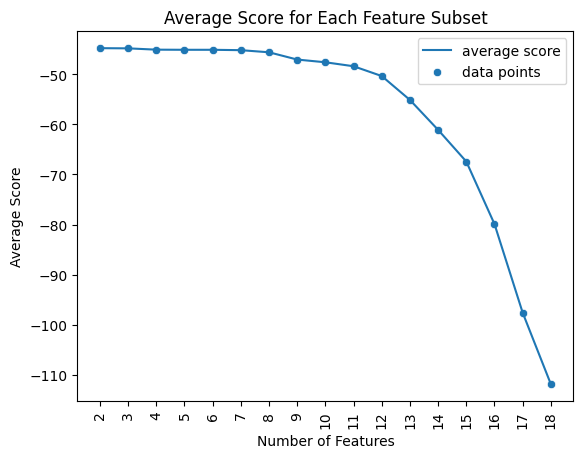

In [89]:
sns.lineplot(data=df_forward, x=df_forward.sort_index().index, y='avg_score', label='average score')

# Create Scatter Plot
sns.scatterplot(data=df_forward, x=df_forward.sort_index().index, y='avg_score', label='data points')

# Add labels in X axis
plt.xticks(df_forward.sort_index().index, labels=df_forward.sort_index().index, rotation=90)

# Add title
plt.title('Average Score for Each Feature Subset')
plt.xlabel('Number of Features')
plt.ylabel('Average Score')
plt.legend()
plt.show()

In [90]:
best_feature_forward = df_forward.head(1)['feature_names'].values[0]
best_feature_forward = list(best_feature_forward)
best_feature_forward

['weather_Cloudy/Misty',
 'weather_Heavy Rain/Heavy Snow',
 'weather_Light Rain/Light Snow',
 'season_Spring',
 'season_Summer',
 'season_Winter',
 'year_2012',
 'holiday_Yes',
 'month_0',
 'month_1',
 'month_3',
 'day_0',
 'day_1',
 'day_2',
 'humidity',
 'atemp',
 'hour']

In [91]:
X_train_forward = df_X_train_scaled.loc[:,best_feature_forward]
X_test_forward = df_X_test_scaled.loc[:,best_feature_forward]

display(X_train_forward,
X_test_forward)

,weather_Cloudy/Misty,weather_Heavy Rain/Heavy Snow,weather_Light Rain/Light Snow,season_Spring,season_Summer,season_Winter,year_2012,holiday_Yes,month_0,month_1,month_3,day_0,day_1,day_2,humidity,atemp,hour
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.333333,0.158041,1.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.433333,-0.578673,-0.666667
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.400000,0.631817,0.000000
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.133333,0.105592,0.250000
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.900000,0.368531,-0.916667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9727,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.100000,-0.526224,-0.416667
9728,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.033333,-0.420980,-0.166667
9729,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.833333,-0.262939,0.833333
9730,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,-1.200000,-0.526224,0.583333


,weather_Cloudy/Misty,weather_Heavy Rain/Heavy Snow,weather_Light Rain/Light Snow,season_Spring,season_Summer,season_Winter,year_2012,holiday_Yes,month_0,month_1,month_3,day_0,day_1,day_2,humidity,atemp,hour
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-0.433333,0.789510,0.500000
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,-0.400000,0.473776,-0.166667
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-0.033333,0.421327,0.916667
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,-0.600000,-0.157694,0.250000
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.566667,0.631817,-0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2428,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.133333,-0.473428,0.750000
2429,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.366667,0.158041,-0.916667
2430,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.800000,-0.999653,-0.250000
2431,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.466667,-0.315735,-0.833333


In [92]:
model_forward = xgb

# fit
model_forward.fit(X_train_forward, y_train)

# predict
y_pred_forward = model_forward.predict(X_test_forward)
y_pred_train_forward = model_forward.predict(X_train_forward)

# scoring
xgb_forward_test_rmse = rmse(y_test, y_pred_forward)
xgb_forward_train_rmse = rmse(y_train, y_pred_train_forward)

xgb_forward_test_mae = mean_absolute_error(y_test, y_pred_forward)
xgb_forward_train_mae = mean_absolute_error(y_train, y_pred_train_forward)

xgb_forward_test_mape = mean_absolute_percentage_error(y_test, y_pred_forward)
xgb_forward_train_mape = mean_absolute_percentage_error(y_train, y_pred_train_forward)

xgb_forward_test_r2 = r2_score(y_test, y_pred_forward)
xgb_forward_train_r2 = r2_score(y_train, y_pred_train_forward)

## Backward Feature Selection

In [93]:
model = xgb

sfs_backward = SFS(
    estimator=xgb,
    k_features=2,
    forward=False,
    verbose=0,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

sfs_backward.fit(df_X_train_scaled, y_train)

SequentialFeatureSelector(estimator=XGBRegressor(base_score=None, booster=None,
                                                 callbacks=None,
                                                 colsample_bylevel=None,
                                                 colsample_bynode=None,
                                                 colsample_bytree=None,
                                                 device=None,
                                                 early_stopping_rounds=None,
                                                 enable_categorical=False,
                                                 eval_metric=None,
                                                 feature_types=None, gamma=None,
                                                 grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=None,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=None, n_jobs=None,
                                                 num_parallel_tree=None,
                                                 random_state=None, ...),
                          forward=False, k_features=(2, 2),
                          scoring='neg_root_mean_squared_error')

In [94]:
# score tiap pengurangan feature
df_backward = pd.DataFrame.from_dict(sfs_backward.get_metric_dict()).T.sort_values(by='avg_score', ascending=False)
df_backward

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
17,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14,...","[-44.312904357910156, -41.29233932495117, -46....",-44.817222,"(weather_Cloudy/Misty, weather_Heavy Rain/Heav...",2.45702,1.911645,0.955823
16,"(0, 1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15...","[-45.43098831176758, -41.784446716308594, -46....",-45.091061,"(weather_Cloudy/Misty, weather_Heavy Rain/Heav...",2.211944,1.720967,0.860484
14,"(2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17)","[-43.51496887207031, -42.00796890258789, -47.2...",-45.114733,"(weather_Light Rain/Light Snow, season_Spring,...",2.583013,2.009672,1.004836
13,"(2, 3, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 17)","[-44.122684478759766, -42.219356536865234, -46...",-45.141394,"(weather_Light Rain/Light Snow, season_Spring,...",2.231443,1.736139,0.868069
18,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[-44.41883850097656, -42.29281234741211, -47.3...",-45.215639,"(weather_Cloudy/Misty, weather_Heavy Rain/Heav...",2.218993,1.726452,0.863226
15,"(1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 1...","[-43.88184356689453, -43.196590423583984, -47....",-45.30811,"(weather_Heavy Rain/Heavy Snow, weather_Light ...",1.959392,1.524473,0.762237
12,"(2, 3, 5, 6, 7, 9, 12, 13, 14, 15, 16, 17)","[-45.58021545410156, -42.397125244140625, -46....",-45.638766,"(weather_Light Rain/Light Snow, season_Spring,...",2.180438,1.696455,0.848227
11,"(2, 3, 5, 6, 7, 9, 12, 13, 14, 16, 17)","[-45.192047119140625, -43.7955322265625, -48.1...",-47.057464,"(weather_Light Rain/Light Snow, season_Spring,...",2.803732,2.181399,1.090699
10,"(2, 3, 5, 6, 7, 12, 13, 14, 16, 17)","[-45.661033630371094, -45.70729064941406, -48....",-47.876926,"(weather_Light Rain/Light Snow, season_Spring,...",2.378021,1.850181,0.92509
9,"(2, 3, 5, 6, 7, 13, 14, 16, 17)","[-47.38105010986328, -45.972450256347656, -48....",-48.422269,"(weather_Light Rain/Light Snow, season_Spring,...",1.994341,1.551665,0.775833


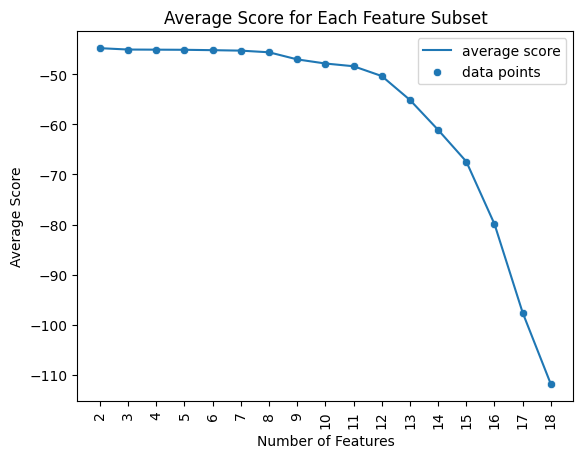

In [95]:
sns.lineplot(data=df_backward, x=df_backward.sort_index().index, y='avg_score', label='average score')

# Create Scatter Plot
sns.scatterplot(data=df_backward, x=df_backward.sort_index().index, y='avg_score', label='data points')

# Add labels in X axis
plt.xticks(df_backward.sort_index().index, labels=df_backward.sort_index().index, rotation=90)

# Add title
plt.title('Average Score for Each Feature Subset')
plt.xlabel('Number of Features')
plt.ylabel('Average Score')
plt.legend()
plt.show()

In [96]:
best_feature_backward = df_backward.head(1)['feature_names'].values[0]
best_feature_backward = list(best_feature_backward)
best_feature_backward

['weather_Cloudy/Misty',
 'weather_Heavy Rain/Heavy Snow',
 'weather_Light Rain/Light Snow',
 'season_Spring',
 'season_Summer',
 'season_Winter',
 'year_2012',
 'holiday_Yes',
 'month_0',
 'month_1',
 'month_3',
 'day_0',
 'day_1',
 'day_2',
 'humidity',
 'atemp',
 'hour']

In [97]:
X_train_backward = df_X_train_scaled.loc[:,best_feature_backward]
X_test_backward = df_X_test_scaled.loc[:,best_feature_backward]

display(X_train_backward, X_test_backward)

,weather_Cloudy/Misty,weather_Heavy Rain/Heavy Snow,weather_Light Rain/Light Snow,season_Spring,season_Summer,season_Winter,year_2012,holiday_Yes,month_0,month_1,month_3,day_0,day_1,day_2,humidity,atemp,hour
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.333333,0.158041,1.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.433333,-0.578673,-0.666667
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.400000,0.631817,0.000000
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.133333,0.105592,0.250000
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.900000,0.368531,-0.916667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9727,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.100000,-0.526224,-0.416667
9728,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.033333,-0.420980,-0.166667
9729,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.833333,-0.262939,0.833333
9730,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,-1.200000,-0.526224,0.583333


,weather_Cloudy/Misty,weather_Heavy Rain/Heavy Snow,weather_Light Rain/Light Snow,season_Spring,season_Summer,season_Winter,year_2012,holiday_Yes,month_0,month_1,month_3,day_0,day_1,day_2,humidity,atemp,hour
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-0.433333,0.789510,0.500000
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,-0.400000,0.473776,-0.166667
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,-0.033333,0.421327,0.916667
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,-0.600000,-0.157694,0.250000
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.566667,0.631817,-0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2428,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.133333,-0.473428,0.750000
2429,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.366667,0.158041,-0.916667
2430,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.800000,-0.999653,-0.250000
2431,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.466667,-0.315735,-0.833333


In [98]:
model_backward = xgb

# fit
model_backward.fit(X_train_backward, y_train)

# predict
y_pred_backward = model_backward.predict(X_test_backward)
y_pred_train_backward = model_backward.predict(X_train_backward)

# scoring
# rmse
xgb_backward_test_rmse = rmse(y_test, y_pred_backward)
xgb_backward_train_rmse = rmse(y_train, y_pred_train_backward)

# mae
xgb_backward_test_mae = mean_absolute_error(y_test, y_pred_backward)
xgb_backward_train_mae = mean_absolute_error(y_train, y_pred_train_backward)

# mape
xgb_backward_test_mape = mean_absolute_percentage_error(y_test, y_pred_backward)
xgb_backward_train_mape = mean_absolute_percentage_error(y_train, y_pred_train_backward)

# r2
xgb_backward_test_r2 = r2_score(y_test, y_pred_backward)
xgb_backward_train_r2 = r2_score(y_train, y_pred_train_backward)

### Perbandingan Benchmark - Feature Selection

In [99]:
df_feature_selection = pd.DataFrame()
df_feature_selection['Model'] = ['XGBoost Bencmark', 'XGBoost Forward', 'XGBoost Backward']
df_feature_selection['RMSE Train'] = [gb_train_rmse, xgb_forward_train_rmse, xgb_backward_train_rmse]
df_feature_selection['RMSE Test'] = [gb_test_rmse, xgb_forward_test_rmse, xgb_backward_test_rmse]
df_feature_selection['MAE Train'] = [gb_train_mae, xgb_forward_train_mae, xgb_backward_train_mae]
df_feature_selection['MAE Test'] = [gb_test_mae, xgb_forward_test_mae, xgb_backward_test_mae]
df_feature_selection['MAPE Train'] = [gb_train_mape, xgb_forward_train_mape, xgb_backward_train_mape]
df_feature_selection['MAPE Test'] = [gb_test_mape, xgb_forward_test_mape, xgb_backward_test_mape]
df_feature_selection['R2 Train'] = [gb_train_r2, xgb_forward_train_r2, xgb_backward_train_r2]
df_feature_selection['R2 Test'] = [gb_test_r2, xgb_forward_test_r2, xgb_backward_test_r2]

df_feature_selection.sort_values(by='RMSE Test')

,Model,RMSE Train,RMSE Test,MAE Train,MAE Test,MAPE Train,MAPE Test,R2 Train,R2 Test
0,XGBoost Bencmark,28.380174,39.961888,18.616919,26.689241,0.344164,0.427012,0.975471,0.951384
1,XGBoost Forward,28.944281,40.594656,18.911816,27.189341,0.332462,0.422423,0.974487,0.949832
2,XGBoost Backward,28.944281,40.594656,18.911816,27.189341,0.332462,0.422423,0.974487,0.949832


In [100]:
df_feature_selection[['Model','RMSE Train', 'MAE Train', 'MAPE Train', 'R2 Train']]

,Model,RMSE Train,MAE Train,MAPE Train,R2 Train
0,XGBoost Bencmark,28.380174,18.616919,0.344164,0.975471
1,XGBoost Forward,28.944281,18.911816,0.332462,0.974487
2,XGBoost Backward,28.944281,18.911816,0.332462,0.974487


## **Model Interpretation**

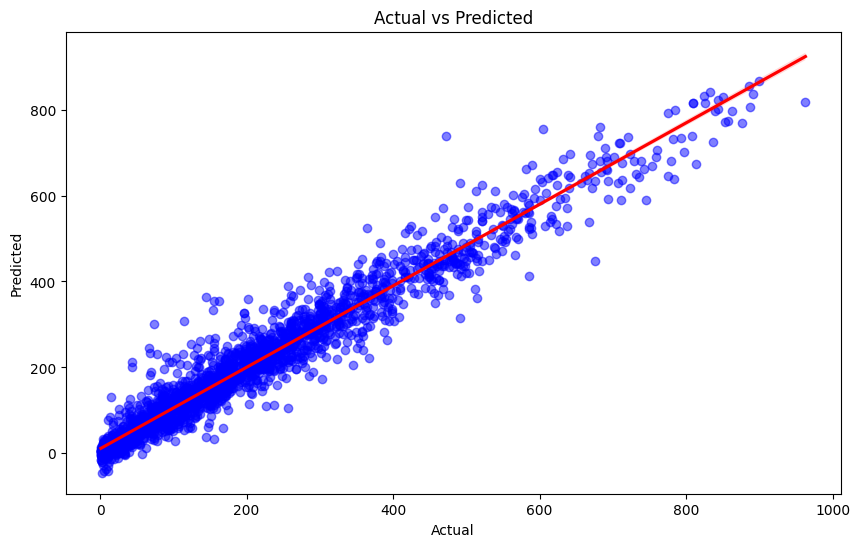

In [101]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5, 'color':'blue'}, line_kws={'color':'red'})
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

Dari grafik regplot diatas dapat ditarik kesimpulan bahwa model mampu melakukan prediksi dengan baik hingga mencapai nilai jumlah sepeda di range 600 unit. Namun, model tidak mampu melakukan prediksi dengan baik di atas nilai 600 unit.

Kita akan mencoba cek evaluasi metrik model dengan menggunakan metrik Mean Absolute Error (MAE) dan Mean Absolute Percentage Error (MAPE) dengan mengelompokkan total_rental pada data test dalam range tertentu.

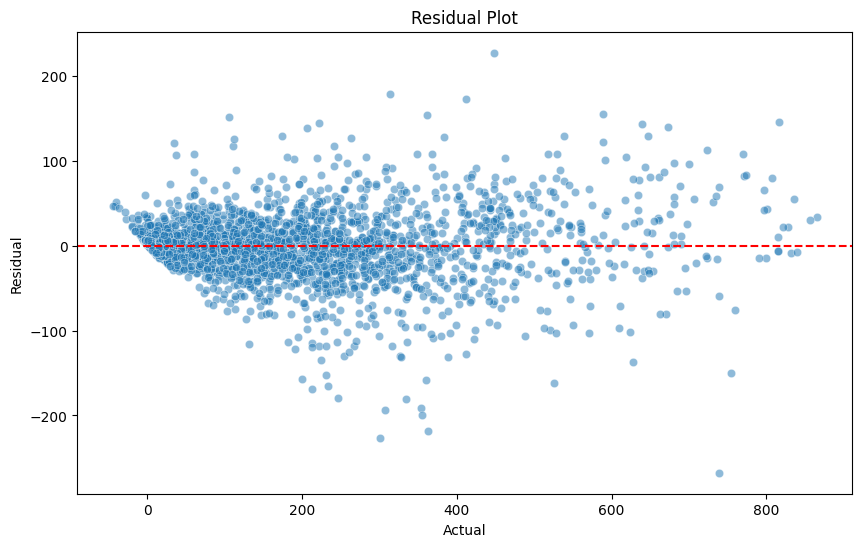

In [102]:
df_error = pd.DataFrame({
    "y_pred": y_pred,
    "error": y_test - y_pred
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_error, x='y_pred', y='error', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

In [103]:
df_target = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'residual': df_error['error']
})

df_50 = df_target[df_target['actual'] <= 50]
df_100 = df_target[(df_target['actual'] > 50) & (df_target['actual'] <= 100)]
df_150 = df_target[(df_target['actual'] > 100) & (df_target['actual'] <= 150)]
df_200 = df_target[(df_target['actual'] > 150) & (df_target['actual'] <= 200)]
df_250 = df_target[(df_target['actual'] > 200) & (df_target['actual'] <= 250)]
df_300 = df_target[(df_target['actual'] > 250) & (df_target['actual'] <= 300)]
df_350 = df_target[(df_target['actual'] > 300) & (df_target['actual'] <= 350)]
df_400 = df_target[(df_target['actual'] > 350) & (df_target['actual'] <= 400)]
df_450 = df_target[(df_target['actual'] > 400) & (df_target['actual'] <= 450)]
df_500 = df_target[(df_target['actual'] > 450) & (df_target['actual'] <= 500)]
df_550 = df_target[(df_target['actual'] > 500) & (df_target['actual'] <= 550)]
df_600 = df_target[(df_target['actual'] > 550) & (df_target['actual'] <= 600)]
df_above_600 = df_target[df_target['actual'] > 600]

range_target = [df_50, df_100, df_150, df_200, df_250, df_300, df_350, df_400, df_450, df_500, df_550, df_600, df_above_600]
index_target = ['<= 50', '51 - 100', '101 - 150', '151 - 200', '201 - 250', '251 - 300', '301 - 350', '351 - 400', '401 - 450', '451 - 500', '501 - 550', '551 - 600', '> 600']
mae = []
mape = []
r2 = []
for i in range(len(range_target)):
    score_mae = mean_absolute_error(range_target[i]['actual'], range_target[i]['predicted'])
    score_mape = mean_absolute_percentage_error(range_target[i]['actual'], range_target[i]['predicted'])
    mae.append(score_mae)
    mape.append(score_mape)

df_eval_metrics = pd.DataFrame({
    'target_range': index_target,
    'mae': mae,
    'mape': mape,
})
df_eval_metrics

,target_range,mae,mape
0,<= 50,11.092545,1.071172
1,51 - 100,26.170160,0.348247
2,101 - 150,27.988848,0.224792
3,151 - 200,29.236172,0.170720
4,201 - 250,28.567541,0.128133
5,251 - 300,30.823025,0.112677
6,301 - 350,34.262917,0.106568
7,351 - 400,42.724106,0.114697
8,401 - 450,33.613544,0.079335
9,451 - 500,46.489758,0.097815


Berdasarkan hasil pengelompokkan target tersebut dapat disimpulkan bahwa untuk target dengan jumlah unit sepeda yang disewa sampai dengan 50 unit memiliki nilai mape yang tinggi (73%).

Dari hasil pengelompokkan tersebut, model dapat memprediksi dengan baik untuk jumlah unit diatas 50 unit, dengan hasil nilai evaluasi metrik yang masih cukup baik.

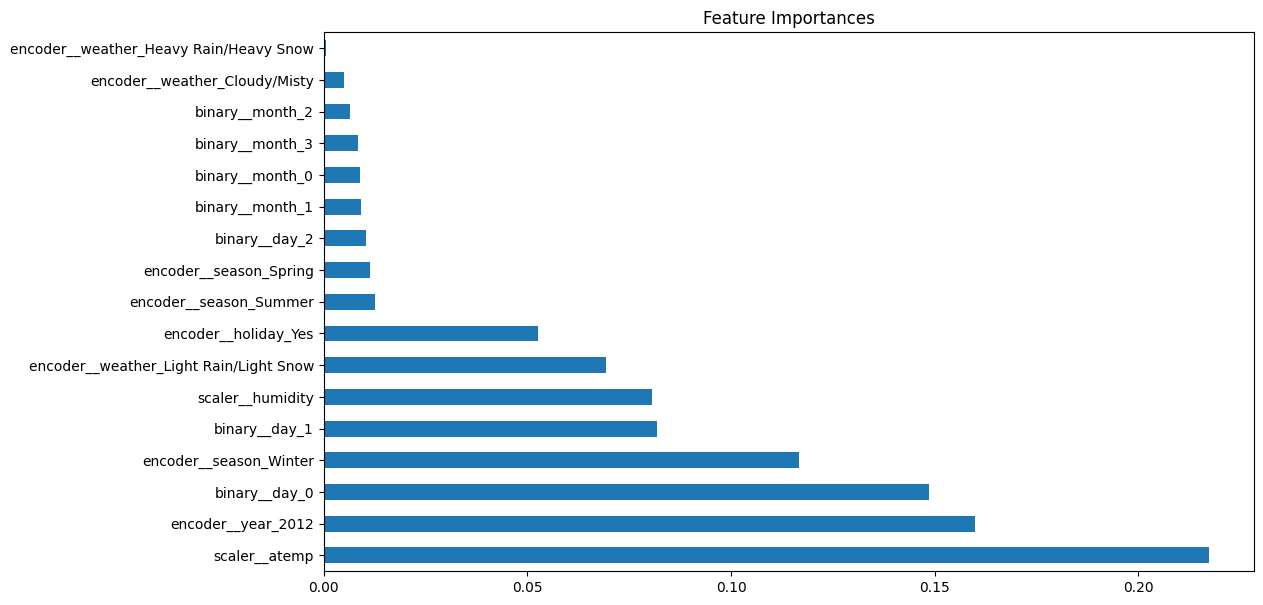

In [104]:
# Plot feature importances
importances = estimator.named_steps['algo'].feature_importances_
feature_names = transformer.get_feature_names_out()
if len(importances) != len(feature_names):
	feature_names = feature_names[:len(importances)]
feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(12, 7))
feature_imp.plot(kind='barh', title='Feature Importances')
plt.show()

Kesimpulan:
Diketahui hasil dari model benchmark dengan menggunakan algoritma XGBoost menghasilkan model dengan prediksi yang lebih baik. Berdasarkan dari pemodelan yang sudah dilakukan, feature `day`, `season` dan `month` menjadi fitur yang paling berpengaruh terhadap `total_rental`.

Evaluasi metrik yang digunakan pada model ini adalah MAE, MAPE, dan R2. Jika dilihat dari nilai MAE yang dihasilkan oleh model benchmark adalah sebesar ~18, dapat disimpulkan bahwa apabila model ini digunakan untuk memprediksi jumlah unit sepeda yang harus disediakan pada rentang nilai yang sudah dilatih dari data training, maka perkiraan jumlah unit yang meleset kurang lebih sebesar 18 unit dari jumlah yang seharusnya.

Namun apabila dilihat pada hasil pengelompokkan berdasarkan rentang target dan visualisasi residual, bisa dilihat limitasi model dapat memprediksi dengan baik untuk jumlah unit sampai berjumlah 600 unit.

# **Kesimpulan berdasarkan Hasil Evaluasi Model:**

1. **Performa Model Terbaik**  
   - Model **XGBoost (XGB)** menunjukkan performa terbaik dibandingkan model lainnya.  
   - XGB memiliki nilai **RMSE** dan **MAE** terendah, yang menunjukkan bahwa error prediksinya lebih kecil.  
   - Nilai **R²** tertinggi pada XGB mengindikasikan bahwa model ini dapat menjelaskan variabilitas data dengan lebih baik dibanding model lainnya.

2. **Akurasi dan Error Model**  
   - Nilai **Mean Absolute Error (MAE)** untuk model XGB sekitar **18**, yang berarti rata-rata prediksi model meleset sekitar 18 unit sepeda dari jumlah sebenarnya.  
   - **Mean Absolute Percentage Error (MAPE)** menunjukkan bahwa model masih memiliki tingkat error relatif terhadap skala data yang perlu diperhatikan.  
   - Model **RandomForest** memiliki nilai MAPE tertinggi, yang berarti kurang andal dibanding XGB.

3. **Batasan Model**  
   - Model mampu memprediksi dengan baik untuk jumlah sepeda hingga **600 unit**.  
   - Namun, untuk jumlah sepeda di atas **600 unit**, model mengalami kesulitan dalam memberikan prediksi yang akurat.  

4. **Fitur yang Paling Berpengaruh**  
   - Variabel yang paling berpengaruh dalam prediksi jumlah sepeda yang disewakan adalah **day (hari), season (musim), dan month (bulan)**.  
   - Faktor waktu memiliki korelasi kuat terhadap tren peminjaman sepeda.

Berikut adalah rekomendasi yang dapat dilakukan untuk meningkatkan akurasi model prediksi jumlah penyewaan sepeda:  

1. **Penambahan variabel fitur**  
   Menambahkan fitur yang lebih berhubungan dengan jumlah penyewaan sepeda, seperti **kondisi cuaca yang lebih detail (kelembaban, indeks UV), tingkat kepadatan penduduk di sekitar stasiun sepeda, jumlah kendaraan di jalan sekitar, serta adanya event khusus di sekitar area tertentu**.  

2. **Peningkatan cakupan data**  
   Data yang digunakan dalam pemodelan dapat diperluas dengan **menambahkan data dari tahun-tahun yang lebih panjang**, sehingga model dapat menangkap pola tren jangka panjang. Selain itu, **menggabungkan data dari kota atau wilayah lain** yang memiliki sistem bike-sharing serupa bisa membantu meningkatkan generalisasi model.  

3. **Pengembangan model untuk analisis strategis**  
   Model yang telah dibuat dapat dikembangkan lebih lanjut untuk **memprediksi jumlah sepeda yang dibutuhkan di setiap lokasi secara real-time**, sehingga operator dapat mengoptimalkan distribusi sepeda di berbagai stasiun. Hal ini juga dapat digunakan sebagai dasar analisis dalam **menentukan lokasi baru untuk stasiun sepeda guna meningkatkan aksesibilitas pengguna**.

**Save Model**

In [105]:
X = df.drop(columns=['total_rentals'])
y = df['total_rentals']

In [106]:
from xgboost import XGBRegressor

In [109]:
import pickle
from xgboost import XGBRegressor

# Save the model
xgb = XGBRegressor(enable_categorical=True)
xgb.fit(X, y)

pickle.dump(xgb, open('Final_Model_Capstone_Module_3_Krisa_Wahyu_Kurniawan.sav', 'wb'))

In [110]:
filename = 'Final_Model_Capstone_Module_3_Krisa_Wahyu_Kurniawan.sav'
loaded_model = pickle.load(open(filename, 'rb'))

In [111]:
print(mean_absolute_error(y_test, loaded_model.predict(X_test)))

16.940876007080078
